In [1]:
import sys
sys.path.insert(0, '/home/bnc2119/MEDAL')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from src.medal.eval_utils import load_and_split, get_teacher_embeddings
from src.medal.core import AutoEncoder
import torch
import matplotlib.ticker as ticker
from pathlib import Path
from sklearn.model_selection import train_test_split
PATH_PREFIX = '/share/ctn/users/bnc2119' 
%load_ext autoreload
%autoreload 2

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-24 20:38:22,626	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-24 20:38:23,161	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
def load_trained_ae(ckpt_path, input_dim, hidden_dims, latent_dim=2, batchnorm=False):
    import sys, os
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, "w")
    model = AutoEncoder(
        input_dim=input_dim,
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation=torch.nn.SELU,            
        bottleneck_activation=None,
        use_batchnorm = batchnorm
    )
    sys.stdout = old_stdout

    sd = torch.load(ckpt_path, map_location="cpu")

    # unwrap to the real state dict
    if isinstance(sd, dict) and "model" in sd and isinstance(sd["model"], dict):
        sd = sd["model"]
    elif isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]

    # remove DDP prefixes if any
    sd = {k.replace("module.", ""): v for k, v in sd.items()}

    # load STRICTLY so we fail fast if something doesn’t match
    missing, unexpected = model.load_state_dict(sd, strict=False)
    print(f"loaded params: {len(sd)} | missing={len(missing)} | unexpected={len(unexpected)}")
    if missing or unexpected:
        print("⚠️ Check architecture/keys. Example missing:", missing[:3], "unexpected:", unexpected[:3])

    model.eval()
    return model


In [3]:
def plot_single_param_recon(student_embed,student_embed_test, per_sample_recon, per_sample_recon_test, labels, test_labels, fig, axes, palette, cmap, norm, plot_legend=False,
                            **fig_kwargs):
    if plot_legend:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=True, palette=palette)
        handles, labels = axes[0].get_legend_handles_labels()
        if getattr(axes[0], "legend_", None) is not None:
            axes[0].legend_.remove()

        # make one shared legend for the whole figure
        fig.legend(
            handles, labels,
            **fig_kwargs
        )
    else:
        sns.scatterplot(x=student_embed[:, 0].detach().numpy(), 
                        y=student_embed[:, 1].detach().numpy(), 
                        ax=axes[0], s=4, hue=labels, legend=False, palette=palette)
    sns.scatterplot(
        x=student_embed[:, 0].detach().numpy(), y=student_embed[:, 1].detach().numpy(),
        hue=per_sample_recon,
        palette=cmap, hue_norm=norm,
        s=8,legend=False, rasterized=True,
        ax=axes[1], 
    )
    sns.scatterplot(x=student_embed_test[:, 0].detach().numpy(), 
                    y=student_embed_test[:, 1].detach().numpy(),  
                    ax=axes[2], hue=test_labels, s=4, marker="x",linewidth=0.5, legend=False, alpha=1, palette=palette)
    sns.scatterplot(
        x=student_embed_test[:, 0].detach().numpy(), y=student_embed_test[:, 1].detach().numpy(),
        hue=per_sample_recon_test,
        palette=cmap, hue_norm=norm,marker="x",
        s=4, legend=False, rasterized=True,
        ax=axes[3], alpha=1, linewidth=0.5,
    )
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test, 0.975)))
    fig.colorbar(sm, ax=axes[1], orientation="horizontal", fraction=0.05, pad=0.02)
    fig.colorbar(sm, ax=axes[3], orientation="horizontal", fraction=0.05, pad=0.02)

def split_scdeed_labels(df, best_param):
    result = []
    for l in ["dubious", "trustworthy", "intermediate"]:
        vec = df.loc[best_param, f"{l}_cells"]
        ls_indices = np.array(vec.split(',')).astype(int)
        result.extend(list(zip([l]* len(ls_indices), ls_indices)))
    return pd.DataFrame(result, columns = ['label', 'index']).set_index('index').sort_index()


In [4]:
X, X_test, y, y_test = load_and_split("cortical", test_size=0.2, seed=0, labels=True)
labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_labels.npy', allow_pickle=True)
colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_cluster_colors.npy', allow_pickle=True)
categories = np.unique(labels)
tasic_palette = {cat: col for cat, col in zip(categories, colors)}

class_labels = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_labels.npy', allow_pickle=True)
y_class, y_class_test = train_test_split(class_labels, test_size=0.2, random_state=0)
class_colors = np.load(Path(PATH_PREFIX) / 'drd_data/tasic_class_colors.npy', allow_pickle=True)
tasic_palette_class = {"Glutamatergic": "#e5b68b", "GABAergic": "#307c47", "Non-Neuronal": "#2C94EF", "Endothelial": "#32D7FC"}

In [8]:
tasic_tsne_res_dict = []
for s in range(5):
    for perp in np.unique(np.logspace(np.log10(5), np.log10(6000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_tsne_{perp}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt/cortical/medal_tsne2_{perp}_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon_tsne = np.mean((student_recon.detach().numpy() - X)**2)
            tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": train_recon_tsne, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon_tsne = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            tasic_tsne_res_dict.append({"perplexity": perp, "recon_loss": test_recon_tsne, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {perp} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


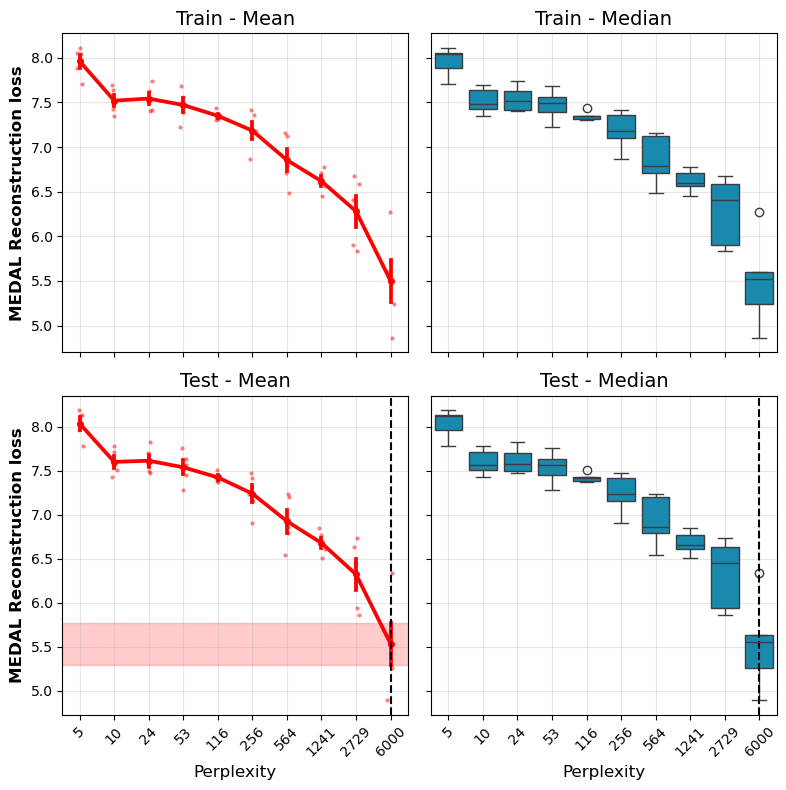

In [9]:
# lr
analysis = pd.DataFrame(tasic_tsne_res_dict)
analysis.sort_values(by='perplexity',inplace=True)
test_stats = analysis[analysis.split == "Test"].groupby('perplexity')['recon_loss'].agg(['mean', 'median', 'sem'])
tsne_argmin_mean = test_stats['mean'].idxmin()
tsne_argmin_median = test_stats['median'].idxmin()
tsne_one_std_range = (test_stats.loc[tsne_argmin_mean, "mean"] - test_stats.loc[tsne_argmin_mean, "sem"], 
                test_stats.loc[tsne_argmin_mean, "mean"] + test_stats.loc[tsne_argmin_mean, "sem"])
tsne_one_std_param_choice = test_stats.loc[(test_stats['mean'] <= tsne_one_std_range[1]) & 
                                           (test_stats['mean'] >= tsne_one_std_range[0])].index.min()
x_coords = range(-1, len(test_stats)+1)
unique_neighbors = sorted(analysis['perplexity'].unique())
pos_mean = unique_neighbors.index(tsne_argmin_mean)
pos_median = unique_neighbors.index(tsne_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)
for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="perplexity", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="perplexity", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="perplexity", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Perplexity", fontsize=12)
        ax.set_ylabel("MEDAL Reconstruction loss", fontsize=12, fontweight='bold')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(x=test_stats.index.get_loc(tsne_one_std_param_choice), ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

axes[1,0].fill_between(
    x_coords, 
    tsne_one_std_range[0], 
    tsne_one_std_range[1], 
    color="red", 
    alpha=0.2, 
    label='1 SEM'
)
axes[1,0].set_xlim(-0.5,9.5)

plt.tight_layout()
plt.show()


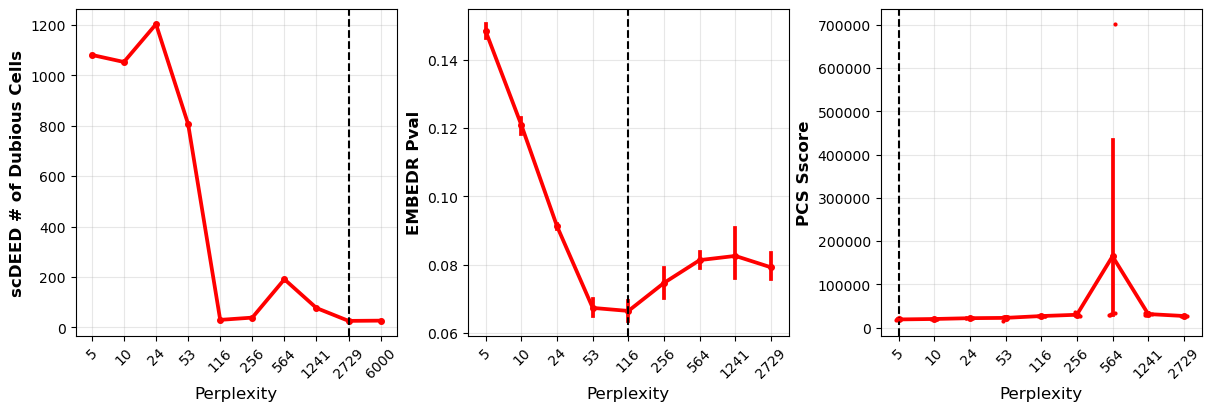

In [8]:
# other methods
fig, axes = plt.subplots(1, 3, figsize=(12,4), constrained_layout=True)
axes_flat = axes.flatten()

## scDEED
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_tsne/tsne_best_tasic_train_num_dubious.csv')
umap_argmin = scdeed_analysis['number_dubious_cells'].idxmin()
argmin_position = scdeed_analysis.index.tolist().index(umap_argmin)

sns.pointplot(data=scdeed_analysis, x='perplexity', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position, ls = '--', c ='black')
axes_flat[0].set_ylabel("scDEED # of Dubious Cells", fontsize=12, fontweight='bold')

## EMBEDR algorithm
embedr_ = pd.concat([
    pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_embedr_tsne/tasic_train_small_{i}/elbow_df.csv')
    for i in range(1,6)
])
embedr_.sort_values(by='perplexity', inplace=True)
embedr_tsne_argmin = embedr_.groupby('perplexity')['mean_embedr_pval'].mean().idxmin()
unique_perp = sorted(embedr_['perplexity'].unique())
pos_mean = unique_perp.index(embedr_tsne_argmin)

sns.pointplot(data=embedr_, x="perplexity", y="mean_embedr_pval", color="red", markersize=3, ax = axes_flat[1])
axes_flat[1].set_ylabel("EMBEDR Pval", fontsize=12, fontweight='bold')       
axes_flat[1].axvline(x=pos_mean, ls='--', c='black')

## PCS Sscore
pcs_ = pd.concat([
    pd.read_csv(Path(PATH_PREFIX) / f'MEDAL/comparisons/results_pcs/tasic_train_small_{i}/elbow_df.csv')
    for i in range(1,6)
])
pcs_.sort_values(by='perplexity', inplace=True)
unique_perp = sorted(pcs_['perplexity'].unique())

pcs_tsne_argmin_sscore = pcs_.groupby('perplexity')['mean_sscore'].mean().idxmin()

pos_mean_sscore = unique_perp.index(pcs_tsne_argmin_sscore)
sns.pointplot(data=pcs_, x="perplexity", y="mean_sscore", color="red", markersize=3, ax=axes_flat[2])
sns.stripplot(data=pcs_, x="perplexity", y="mean_sscore", color="red", size=3, ax=axes_flat[2])
axes_flat[2].set_ylabel("PCS Sscore", fontsize=12, fontweight='bold')    
axes_flat[2].axvline(x=pos_mean_sscore, ls='--', c='black')

for i in [0,1,2]:
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xlabel("Perplexity", fontsize=12)
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='center')

plt.show()

In [9]:
tasic_umap_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(2000), 10).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_umap_{n}_0.1_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt/cortical/medal_umap2_{n}_0.1_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm = True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            tasic_umap_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

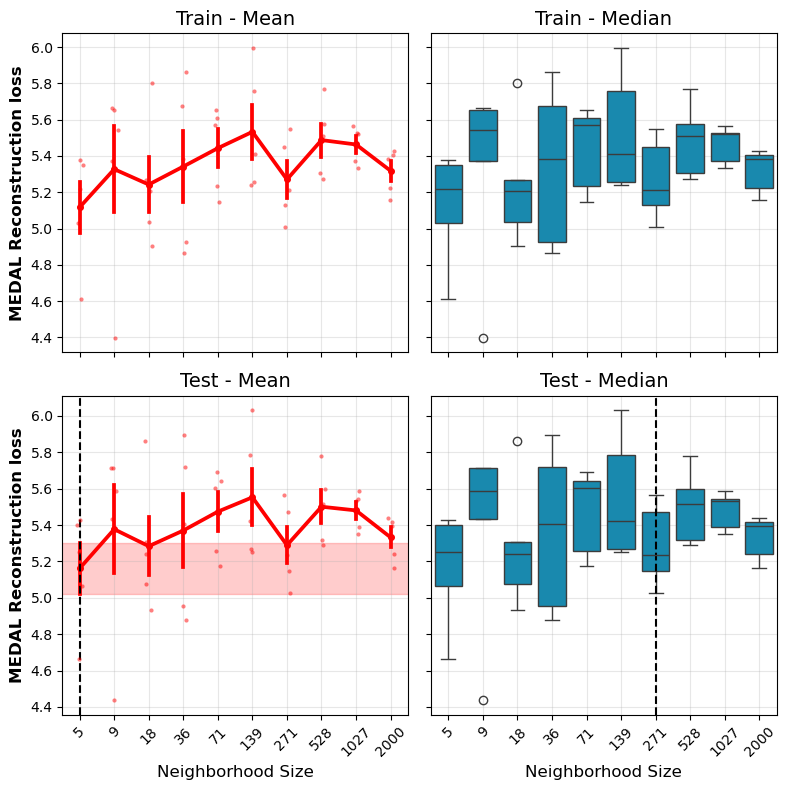

In [10]:
analysis = pd.DataFrame(tasic_umap_res_dict)
analysis.sort_values(by='n_neighbors', inplace=True)
test_stats = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].agg(['mean', 'median','sem'])
umap_argmin_mean = test_stats['mean'].idxmin()
umap_argmin_median = test_stats['median'].idxmin()
umap_one_std_range = (test_stats.loc[umap_argmin_mean, "mean"] - test_stats.loc[umap_argmin_mean, "sem"], 
                test_stats.loc[umap_argmin_mean, "mean"] + test_stats.loc[umap_argmin_mean, "sem"])
umap_one_std_param_choice = test_stats.loc[(test_stats['mean'] <= umap_one_std_range[1]) & 
                                           (test_stats['mean'] >= umap_one_std_range[0])].index.min()
x_coords = range(-1, len(test_stats)+1)
unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(umap_argmin_mean)
pos_median = unique_neighbors.index(umap_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("MEDAL Reconstruction loss", fontsize=12, fontweight='bold')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(
            x=test_stats.index.get_loc(umap_one_std_param_choice), ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

axes[1,0].fill_between(
    x_coords, 
    umap_one_std_range[0], 
    umap_one_std_range[1], 
    color="red", 
    alpha=0.2, 
    label='1 SEM'
    )
axes[1,0].set_xlim(-0.5,9.5)
plt.tight_layout()
plt.show()

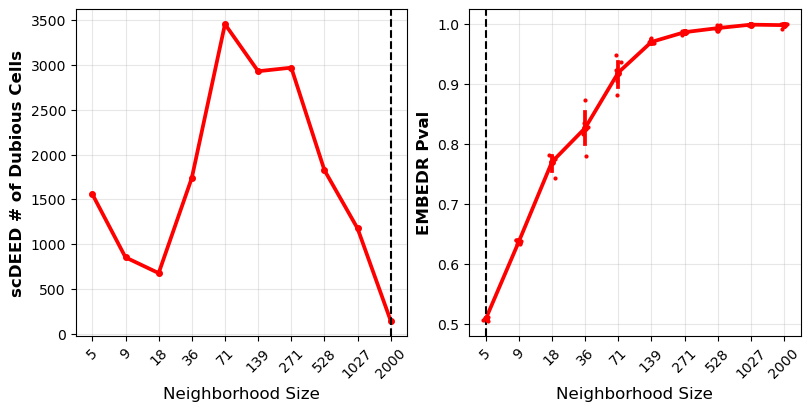

In [12]:
# other methods
fig, axes = plt.subplots(1, 2, figsize=(8,4), constrained_layout=True)
axes_flat = axes.flatten()

## scDEED
scdeed_analysis = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/umap_best_tasic_train_num_dubious.csv')
umap_argmin = scdeed_analysis['number_dubious_cells'].idxmin()
argmin_position = scdeed_analysis.index.tolist().index(umap_argmin)

sns.pointplot(data=scdeed_analysis, x='n_neighbors', y='number_dubious_cells', color='red', markersize=3, ax = axes_flat[0])
axes_flat[0].axvline(x = argmin_position, ls = '--', c ='black')
axes_flat[0].set_ylabel("scDEED # of Dubious Cells", fontsize=12, fontweight='bold')

## EMBEDR algorithm
embedr_ = pd.concat([
    pd.read_csv(Path(PATH_PREFIX)/ f'MEDAL/comparisons/results_embedr_umap/tasic_train_small_{i}/elbow_df.csv')
    for i in range(1,6)
])
embedr_.sort_values(by='n_neighbors', inplace=True)
embedr_umap_argmin = embedr_.groupby('n_neighbors')['mean_embedr_pval'].mean().idxmin()
unique_perp = sorted(embedr_['n_neighbors'].unique())
pos_mean = unique_perp.index(embedr_umap_argmin)

sns.pointplot(data=embedr_, x="n_neighbors", y="mean_embedr_pval", color="red", markersize=3, ax = axes_flat[1])
sns.stripplot(data=embedr_, x="n_neighbors", y="mean_embedr_pval", color="red", size=3, ax = axes_flat[1])
    
axes_flat[1].set_ylabel("EMBEDR Pval", fontsize=12, fontweight='bold')       
axes_flat[1].axvline(x=pos_mean, ls='--', c='black')

for i in [0,1]:
    axes_flat[i].grid(True, alpha=0.3)
    axes_flat[i].set_xlabel("Neighborhood Size", fontsize=12)
    plt.setp(axes_flat[i].get_xticklabels(), rotation=45, ha='center')

plt.show()

In [16]:
tasic_spectral_res_dict = []
for s in range(5):
    for n in np.unique(np.logspace(np.log10(5), np.log10(200), 15).astype(int)):
        teacher_embed = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_spectral_{n}_0_train.npy")
        student = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt/cortical/spectral2_{n}_{s}_ckpts/final.pt",
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm = True)
        
        student_recon, student_embed = student(torch.tensor(X, dtype=torch.float32))
        train_distill = np.mean((teacher_embed - student_embed.detach().numpy()) ** 2)
        if train_distill < 1e-5:
            train_recon = np.mean((student_recon.detach().numpy() - X)**2)
            tasic_spectral_res_dict.append({"n_neighbors": n, "recon_loss": train_recon, "split": "Train", "seed": s})

            x_test_recon, _ = student(torch.tensor(X_test, dtype=torch.float32))
            test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
            tasic_spectral_res_dict.append({"n_neighbors": n, "recon_loss": test_recon, "split": "Test", "seed": s})
        else:
            print(f"Skipping param {n} seed {s} due to distillation loss {train_distill}")

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded par

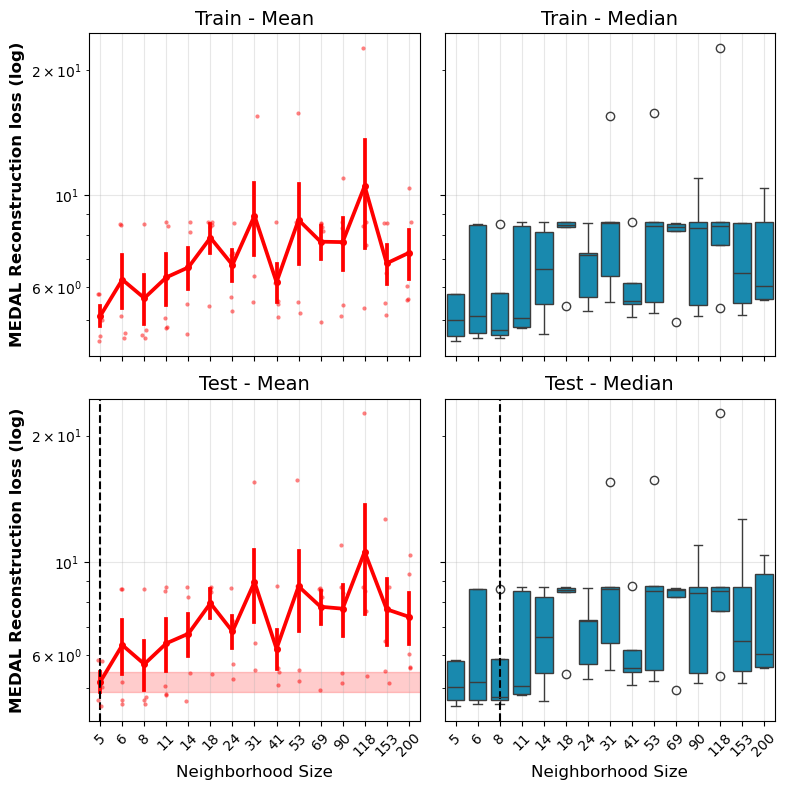

In [33]:
analysis = pd.DataFrame(tasic_spectral_res_dict)
analysis.sort_values(by='n_neighbors',inplace=True)
test_stats = analysis[analysis.split == "Test"].groupby('n_neighbors')['recon_loss'].agg(['mean', 'median', 'sem'])
spectral_argmin_mean = test_stats['mean'].idxmin()
spectral_argmin_median = test_stats['median'].idxmin()
spectral_one_std_range = (test_stats.loc[spectral_argmin_mean, "mean"] - test_stats.loc[spectral_argmin_mean, "sem"], 
                test_stats.loc[spectral_argmin_mean, "mean"] + test_stats.loc[spectral_argmin_mean, "sem"])
spectral_one_std_param_choice = test_stats.loc[(test_stats['mean'] <= spectral_one_std_range[1]) & 
                                           (test_stats['mean'] >= spectral_one_std_range[0])].index.min()
x_coords = range(-1, len(test_stats)+1)
unique_neighbors = sorted(analysis['n_neighbors'].unique())
pos_mean = unique_neighbors.index(spectral_argmin_mean)
pos_median = unique_neighbors.index(spectral_argmin_median)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), sharey='row', sharex=True)

for i, split in enumerate(['Train', 'Test']):
    subset = analysis[analysis.split == split]
    
    # Left Column: Pointplot + Stripplot
    ax_point = axes[i, 0]
    sns.pointplot(data=subset, x="n_neighbors", y="recon_loss", errorbar="se", 
                  color="red", ax=ax_point, markersize=3)
    sns.stripplot(data=subset, x="n_neighbors", y="recon_loss", 
                  color="red", size=3, alpha=0.5, ax=ax_point)
    
    ax_point.set_title(f"{split} - Mean", fontsize=14)
    
    # Right Column: Boxplot
    ax_box = axes[i, 1]
    sns.boxplot(data=subset, x="n_neighbors", y="recon_loss", ax=ax_box, color='#0096C7')
    ax_box.set_title(f"{split} - Median", fontsize=14)
    
    for ax in [ax_point, ax_box]:
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Neighborhood Size", fontsize=12)
        ax.set_ylabel("MEDAL Reconstruction loss (log)", fontsize=12, fontweight='bold')
        plt.setp(ax.get_xticklabels(), rotation=45, ha='center')
        
    if split == "Test":
        ax_point.axvline(
            x=test_stats.index.get_loc(spectral_one_std_param_choice), ls='--', c='black')
        ax_box.axvline(x=pos_median, ls='--', c='black')

axes[1,0].fill_between(
    x_coords, 
    spectral_one_std_range[0], 
    spectral_one_std_range[1], 
    color="red", 
    alpha=0.2, 
    label='1 SEM'
    )
axes[1,0].set_xlim(-0.5,14.5)
plt.tight_layout()
plt.show()

In [14]:
tasic_pca_res_dict = []
for s in range(5):
    student_pca = load_trained_ae(Path(PATH_PREFIX) / f"drd_data/tmp_results/chkpt/cortical/pca2_{s}_ckpts/final.pt",
                                  input_dim=1000,
                                  hidden_dims=[309, 1792, 1792, 1792],
                                  latent_dim=2, batchnorm=True)
    
    student_recon_pca, student_embed_pca = student_pca(torch.tensor(X, dtype=torch.float32))
    train_recon = np.mean((student_recon_pca.detach().numpy() - X)**2)
    tasic_pca_res_dict.append({"recon_loss": train_recon, "split": "Train", "seed": s})

    x_test_recon, _ = student_pca(torch.tensor(X_test, dtype=torch.float32))
    test_recon = np.mean((x_test_recon.detach().numpy() - X_test)**2)
    tasic_pca_res_dict.append({"recon_loss": test_recon, "split": "Test", "seed": s})

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


In [ ]:
tsne_analysis = pd.DataFrame(tasic_tsne_res_dict)
tsne_analysis = tsne_analysis.loc[(tsne_analysis.split=='Test'),:]
tsne_analysis_agg = tsne_analysis.loc[:, ['perplexity','recon_loss']].groupby('perplexity').agg('mean').reset_index()
umap_analysis = pd.DataFrame(tasic_umap_res_dict)
umap_analysis = umap_analysis.loc[(umap_analysis.split=='Test'), :]
umap_analysis_agg = umap_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()
spectral_analysis = pd.DataFrame(tasic_spectral_res_dict)
spectral_analysis = spectral_analysis.loc[(spectral_analysis.split=='Test'), :]
spectral_analysis_agg = spectral_analysis.loc[:, ['n_neighbors','recon_loss']].groupby('n_neighbors').agg('mean').reset_index()

pca_analysis = pd.DataFrame(tasic_pca_res_dict)
pca_analysis = pca_analysis.loc[(pca_analysis.split=='Test'), :]

tsne_best = tsne_analysis.loc[tsne_analysis.perplexity == tsne_argmin_mean, ['recon_loss', 'seed']]
tsne_best['method'] = f'TSNE(perplexity={tsne_one_std_param_choice})'
umap_best = umap_analysis.loc[umap_analysis.n_neighbors == umap_argmin_mean, ['recon_loss', 'seed']]
umap_best['method'] = f'UMAP(n_neighbors={umap_one_std_param_choice})'
spectral_best = spectral_analysis.loc[spectral_analysis.n_neighbors == spectral_argmin_mean, ['recon_loss', 'seed']]
spectral_best['method'] = f'Spectral(n_neighbors={spectral_one_std_param_choice})'
pca_best = pca_analysis[['recon_loss', 'seed']]
pca_best['method'] = 'PCA'
teachers = pd.concat([tsne_best, umap_best, spectral_best, pca_best])

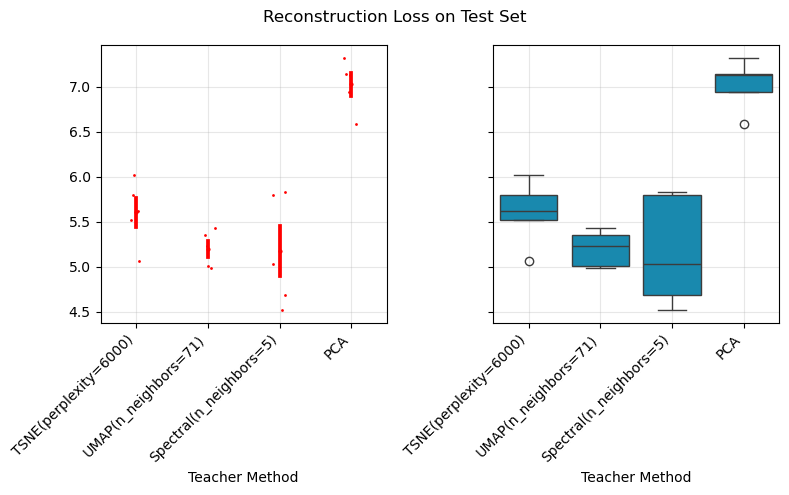

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(8,5), sharey=True)
sns.pointplot(data=teachers, x = 'method', y='recon_loss', linestyles='none', markersize=1, errorbar='se', ax = axes[0], color='red')
sns.stripplot(data=teachers, x = 'method', y='recon_loss', size=2, ax = axes[0], color='red')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel("")
axes[0].set_xlabel("Teacher Method")

sns.boxplot(data=teachers, x = 'method', y='recon_loss', ax = axes[1], color='#0096C7')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("")

axes[0].grid(True, alpha=0.3)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Teacher Method")
fig.suptitle("Reconstruction Loss on Test Set")

plt.tight_layout()

## Reconstruction Analysis

In [39]:
list_umap_param = [71, 271, 2000]
student_umap01 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/umap2_{list_umap_param[0]}_0.1_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_umap01, student_embed_umap01 = student_umap01(torch.tensor(X, dtype=torch.float32))
student_recon_test_umap01, student_embed_test_umap01 = student_umap01(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_umap01 = np.mean((student_recon_umap01.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_umap01 = np.mean((student_recon_test_umap01.detach().numpy() - X_test)**2, axis=1)

student_umap02 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/umap2_{list_umap_param[1]}_0.1_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_umap02, student_embed_umap02 = student_umap02(torch.tensor(X, dtype=torch.float32))
student_recon_test_umap02, student_embed_test_umap02 = student_umap02(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_umap02 = np.mean((student_recon_umap02.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_umap02 = np.mean((student_recon_test_umap02.detach().numpy() - X_test)**2, axis=1)

student_umap03 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/umap2_{list_umap_param[2]}_0.1_1_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_umap03, student_embed_umap03 = student_umap03(torch.tensor(X, dtype=torch.float32))
student_recon_test_umap03, student_embed_test_umap03 = student_umap03(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_umap03 = np.mean((student_recon_umap03.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_umap03 = np.mean((student_recon_test_umap03.detach().numpy() - X_test)**2, axis=1)

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


Text(0.5, 0.98, 'Reconstruction error over embedding after matching UMAP teacher')

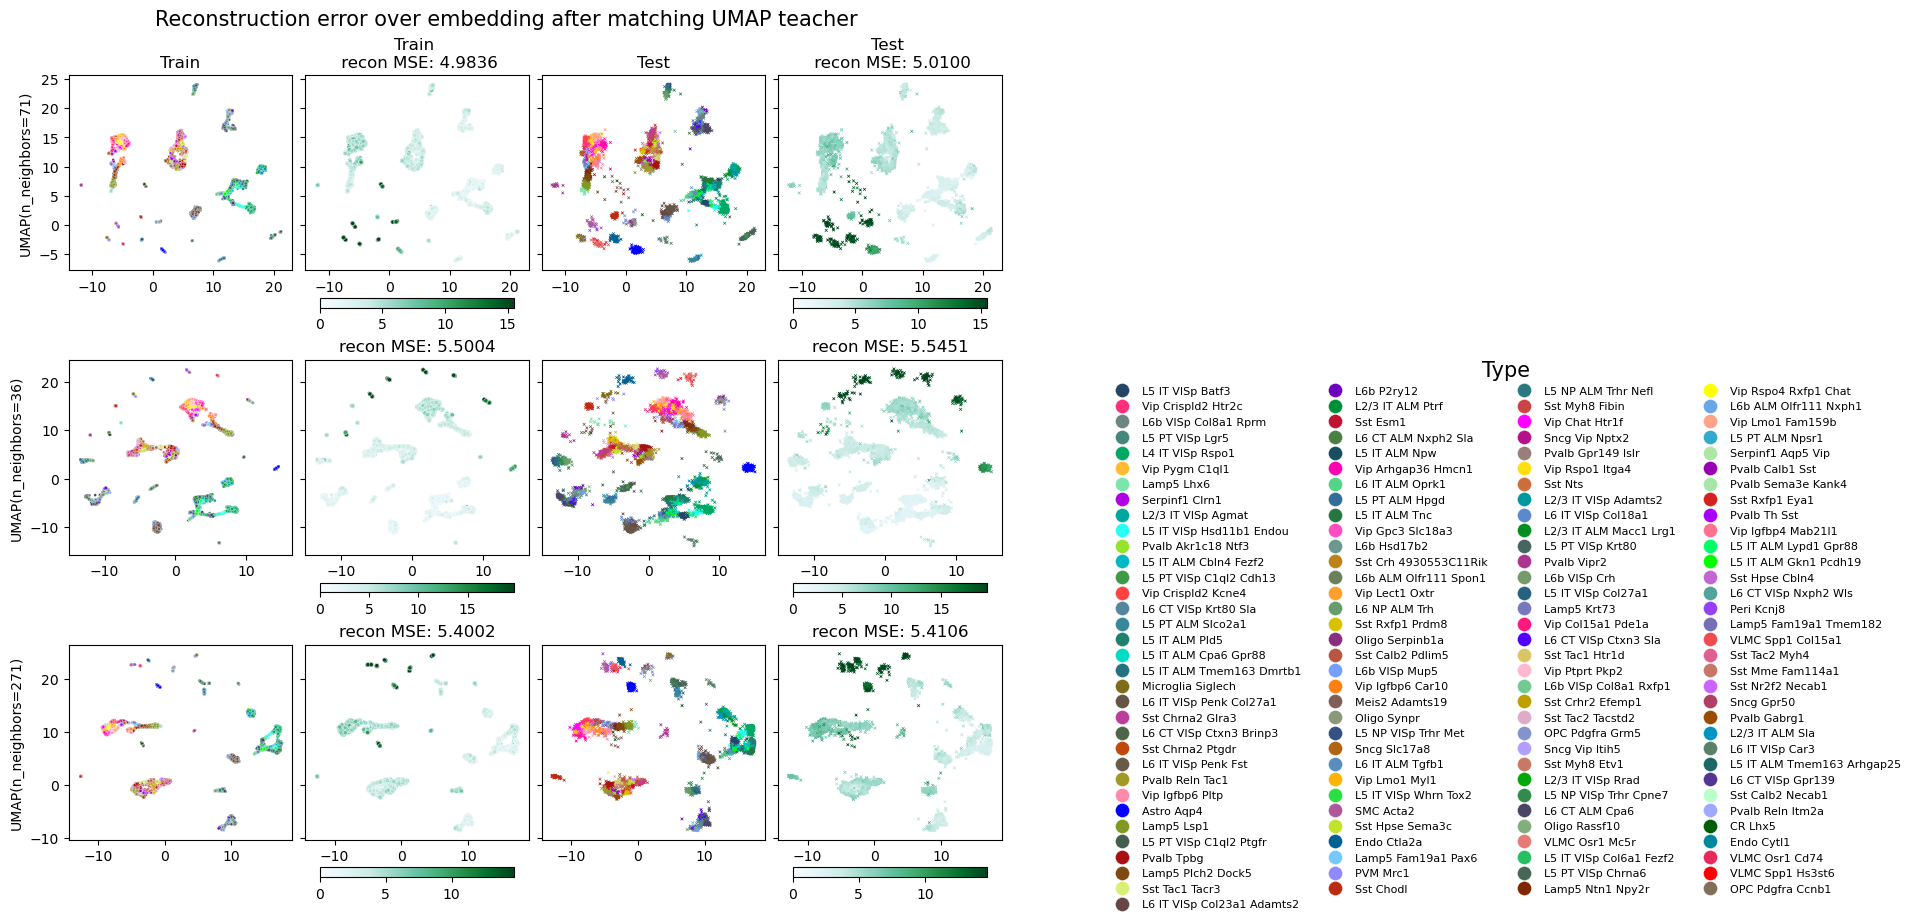

In [6]:
cmap = sns.color_palette("BuGn", as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=16)
fig, axes = plt.subplots(3, 4, figsize=(10, 9), sharey='row', sharex='row', constrained_layout=True)
axes_flat = axes.flatten()
plot_single_param_recon(student_embed_umap01, student_embed_test_umap01, per_sample_recon_umap01, per_sample_recon_test_umap01, y, y_test, fig, axes_flat[0:4], tasic_palette, cmap, 
                        plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test_umap01, 0.975)), 
                        plot_legend=True, loc='center', bbox_to_anchor=(1.5, 0.3), frameon=False, title='Type', ncol=4, fontsize=8, markerscale=5, title_fontsize=15)
plot_single_param_recon(student_embed_umap02, student_embed_test_umap02, per_sample_recon_umap02, per_sample_recon_test_umap02, y, y_test, fig, axes_flat[4:8], tasic_palette, cmap,
                       plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test_umap02, 0.975)))
plot_single_param_recon(student_embed_umap03, student_embed_test_umap03, per_sample_recon_umap03, per_sample_recon_test_umap03, y, y_test, fig, axes_flat[8:12], tasic_palette, cmap,
                       plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test_umap03, 0.975)))
axes_flat[0].set_ylabel(f"UMAP(n_neighbors={list_umap_param[0]})")
axes_flat[4].set_ylabel(f"UMAP(n_neighbors={list_umap_param[1]})")
axes_flat[8].set_ylabel(f"UMAP(n_neighbors={list_umap_param[2]})")
axes_flat[0].set_title("Train")
axes_flat[1].set_title(f"Train \n recon MSE: {per_sample_recon_umap01.mean():.4f}")
axes_flat[5].set_title(f"recon MSE: {per_sample_recon_umap02.mean():.4f}")
axes_flat[9].set_title(f"recon MSE: {per_sample_recon_umap03.mean():.4f}")

axes_flat[2].set_title("Test")
axes_flat[3].set_title(f"Test \n recon MSE: {per_sample_recon_test_umap01.mean():.4f}")
axes_flat[7].set_title(f"recon MSE: {per_sample_recon_test_umap02.mean():.4f}")
axes_flat[11].set_title(f"recon MSE: {per_sample_recon_test_umap03.mean():.4f}")

fig.suptitle("Reconstruction error over embedding after matching UMAP teacher", fontsize=15)

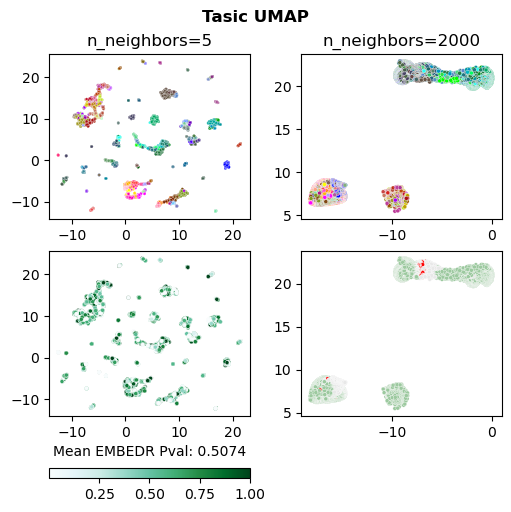

In [15]:
methods = ['scdeed', 'embedr']
import matplotlib.colors as mcolors
scdeed_best, embedr_best = 2000, 5

teacher_embed = dict.fromkeys(methods)
for m in methods:
    if m == "scdeed":
        teacher_embed[m] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/tasic_train_umap_{locals()[f'{m}_best']}_0.1_0_train_pc4.npy")
    else:
        teacher_embed[m] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_umap_{locals()[f'{m}_best']}_0.1_0_train_1.npy")

indices = np.load(Path(PATH_PREFIX) / "MEDAL/comparisons/data/tasic_og_idx1.npy")
embedr_df = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_umap/tasic_train_small_1/X_with_best_scores.csv')
per_sample_embedr = embedr_df[f'embedr_pval_meanbest_{embedr_best}']

scdeed_df = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_scdeed_umap/umap_best_tasic_train_full_results.csv', index_col=0)
per_sample_scdeed = split_scdeed_labels(scdeed_df, scdeed_best)['label']
palette_scdeed = {'dubious': 'red', 'intermediate': '#e8e8e8', 'trustworthy': "#9cc99f"}

cmap = sns.color_palette("BuGn", as_cmap=True)
fig, axes = plt.subplots(2, 2, figsize=(5, 5), constrained_layout=True)
axes_flat = axes.flatten()

# 1st column - EMBEDR Sscore
sns.scatterplot(x=teacher_embed['embedr'][:,0], y=teacher_embed['embedr'][:,1], s=4, hue=y[indices], palette=tasic_palette, legend=False, ax = axes_flat[0])
sns.scatterplot(x=teacher_embed['embedr'][:,0], y=teacher_embed['embedr'][:,1], hue=per_sample_embedr, palette=cmap, 
                hue_norm=mcolors.Normalize(vmax=np.quantile(per_sample_embedr, 0.975)), 
                s=8,legend=False, rasterized=True, ax = axes_flat[2])
handles, labels = axes_flat[0].get_legend_handles_labels()
if getattr(axes_flat[0], "legend_", None) is not None:
    axes_flat[0].legend_.remove()
    # make one shared legend for the whole figure
    fig.legend(handles, labels,loc='center', bbox_to_anchor=(1.09, 0.52), frameon=False, title='Cluster', ncol=1, fontsize=15, markerscale=5, title_fontsize=15)
    
axes_flat[0].set_title(f"n_neighbors={embedr_best}")
axes_flat[2].set_xlabel(f"Mean EMBEDR Pval: {per_sample_embedr.mean():.4f}")

# 2nd column - Scdeed
sns.scatterplot(x=teacher_embed['scdeed'][:, 0], y=teacher_embed['scdeed'][:, 1], 
                ax=axes_flat[1], s=8, hue=y, legend=False, palette=tasic_palette)
sns.scatterplot(x=teacher_embed['scdeed'][:, 0], y=teacher_embed['scdeed'][:, 1], 
                ax=axes_flat[3], s=8, hue = per_sample_scdeed, palette = palette_scdeed, legend=False)
axes_flat[1].set_title(f"n_neighbors={scdeed_best}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin =per_sample_embedr.min(),vmax=np.quantile(per_sample_embedr, 0.975)))
fig.colorbar(sm, ax=axes_flat[2], orientation="horizontal")
fig.suptitle("Tasic UMAP", fontweight='bold')
plt.show()

In [33]:
by_k_umap = pd.read_csv('tasic_by_k_umap.csv', index_col=0)

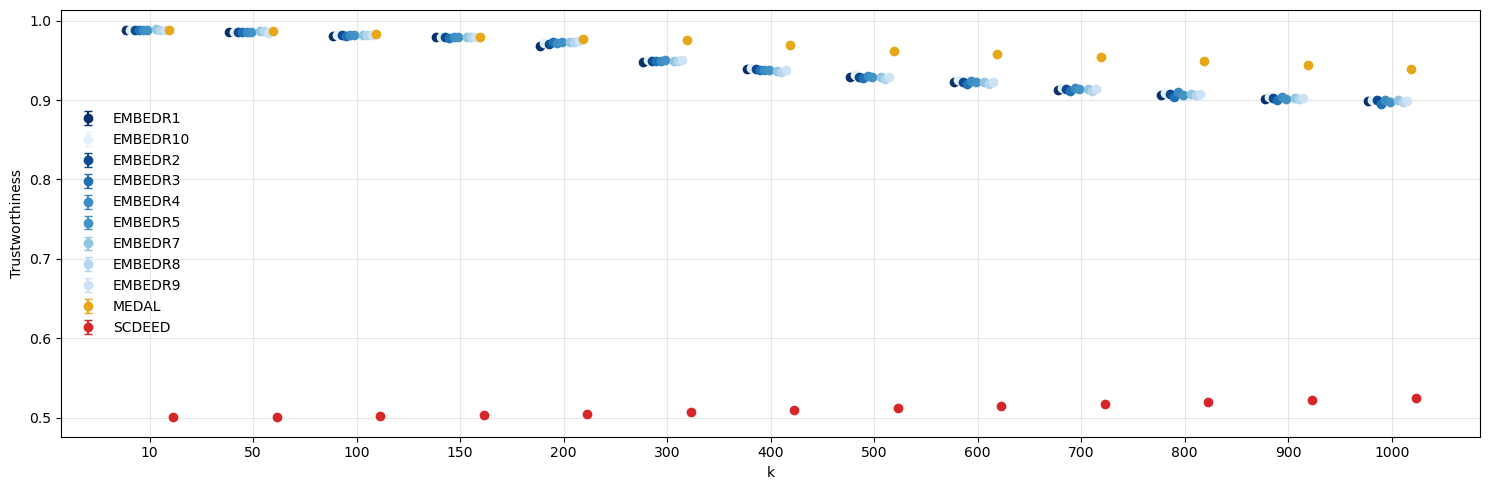

In [37]:
by_k_umap = by_k_umap.sort_values(by = ['k', "method"])
groups = by_k_umap["k"].unique()
methods = by_k_umap["method"].unique()

color_palette = {
    "EMBEDR1":  "#08306b",
    "EMBEDR2":  "#0d4a8f",
    "EMBEDR3":  "#2171b5",
    "EMBEDR4":  "#3a8cc4",
    "EMBEDR5":  "#4292c6",
    "EMBEDR6":  "#6aaed6",
    "EMBEDR7":  "#92c5e0",
    "EMBEDR8":  "#b3d6ee",
    "EMBEDR9":  "#cde3f5",
    "EMBEDR10": "#e3f1fb",
    "MEDAL":    "#e6a817",
    "SCDEED":   "#d62728",
}
group_gap = 1.2        
x = np.arange(len(groups)) * group_gap
z = 1.96  # 95% CI

delta = 0.05  # vertical spacing between methods
offsets = (np.arange(len(methods)) - (len(methods) - 1) / 2) * delta

plt.figure(figsize=(15, 5))

for i, m in enumerate(methods):
    if m in ['EMBEDR6', 'PCS_SS6']: continue
    sub = by_k_umap[by_k_umap["method"] == m].set_index("k").loc[groups]
    plt.errorbar(
        x=x + offsets[i],
        y=sub["train_tw_mean"],
        yerr=z * sub["train_tw_stderr"],
        fmt="o",
        capsize=3,
        label=m,
        color=color_palette[m]
    )

plt.xticks(x, groups)
plt.ylabel("Trustworthiness")
plt.xlabel("k")
plt.legend(frameon=False, loc='center left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


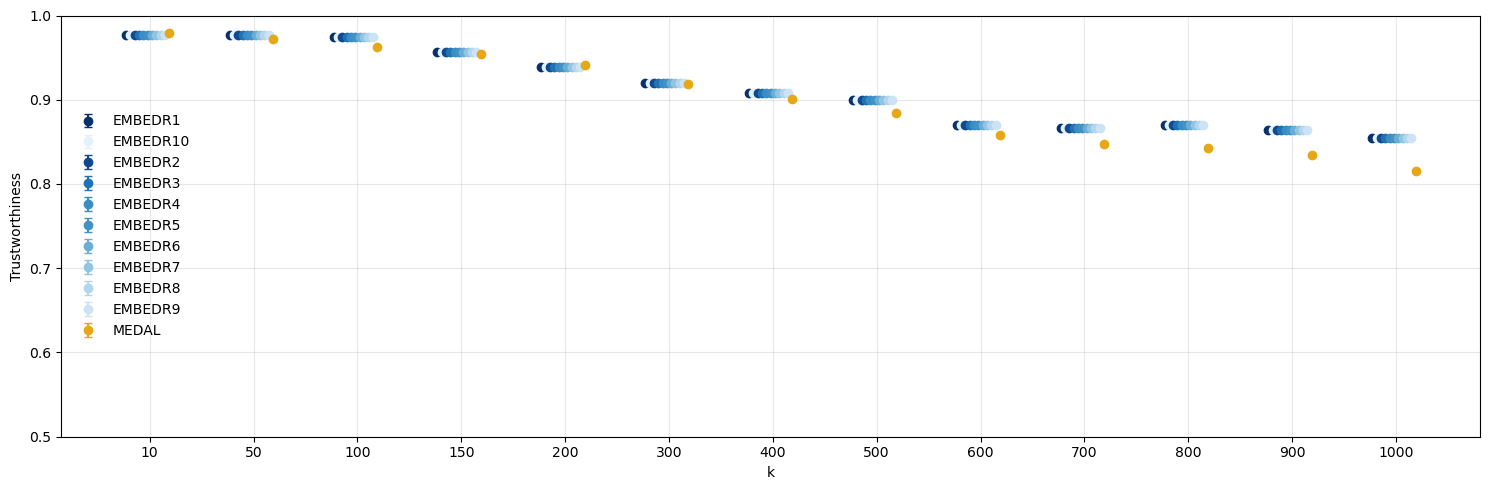

In [40]:
group_gap = 1.2        
x = np.arange(len(groups)) * group_gap
z = 1.96  # 95% CI

delta = 0.05  # vertical spacing between methods
offsets = (np.arange(len(methods)) - (len(methods) - 1) / 2) * delta

plt.figure(figsize=(15, 5))

for i, m in enumerate(methods):
    if m in ['SCDEED']: continue
    sub = by_k_umap[by_k_umap["method"] == m].set_index("k").loc[groups]
    plt.errorbar(
        x=x + offsets[i],
        y=sub["test_tw_mean"],
        yerr=z * sub["test_tw_stderr"],
        fmt="o",
        capsize=3,
        label=m,
        color=color_palette[m]
    )

plt.xticks(x, groups)
plt.ylabel("Trustworthiness")
plt.xlabel("k")
plt.ylim(0.5, 1)
plt.legend(frameon=False, loc='center left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [43]:
list_tsne_param = [2729, 1241, 5]
student_tsne01 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/medal_tsne2_{list_tsne_param[0]}_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_tsne01, student_embed_tsne01 = student_tsne01(torch.tensor(X, dtype=torch.float32))
student_recon_test_tsne01, student_embed_test_tsne01 = student_tsne01(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_tsne01 = np.mean((student_recon_tsne01.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_tsne01 = np.mean((student_recon_test_tsne01.detach().numpy() - X_test)**2, axis=1)

student_tsne02 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/medal_tsne2_{list_tsne_param[1]}_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_tsne02, student_embed_tsne02 = student_tsne02(torch.tensor(X, dtype=torch.float32))
student_recon_test_tsne02, student_embed_test_tsne02 = student_tsne02(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_tsne02 = np.mean((student_recon_tsne02.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_tsne02 = np.mean((student_recon_test_tsne02.detach().numpy() - X_test)**2, axis=1)

student_tsne03 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/medal_tsne2_{list_tsne_param[2]}_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_tsne03, student_embed_tsne03 = student_tsne03(torch.tensor(X, dtype=torch.float32))
student_recon_test_tsne03, student_embed_test_tsne03 = student_tsne03(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_tsne03 = np.mean((student_recon_tsne03.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_tsne03 = np.mean((student_recon_test_tsne03.detach().numpy() - X_test)**2, axis=1)

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


Text(0.5, 0.98, 'Reconstruction error over embedding after matching TSNE teacher')

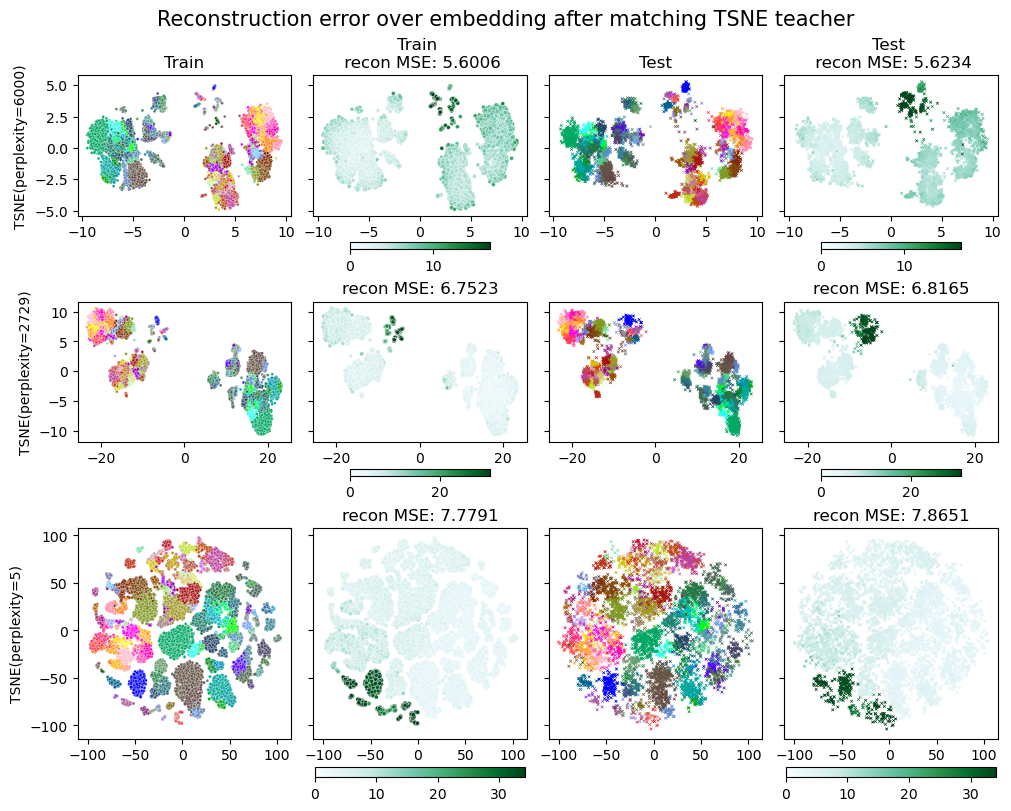

In [21]:
cmap = sns.color_palette("BuGn", as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=16)
fig, axes = plt.subplots(3, 4, figsize=(10, 8), sharey='row', sharex='row', constrained_layout=True, height_ratios=[0.2, 0.2, 0.3])
axes_flat = axes.flatten()
plot_single_param_recon(student_embed_tsne01, student_embed_test_tsne01, per_sample_recon_tsne01, per_sample_recon_test_tsne01, y, y_test, fig, axes_flat[0:4], tasic_palette, cmap, 
                        plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_tsne01, 0.975)), 
                        plot_legend=False, loc='center', bbox_to_anchor=(1.5, 0.3), frameon=False, title='Type', ncol=4, fontsize=8, markerscale=5, title_fontsize=15)
plot_single_param_recon(student_embed_tsne02, student_embed_test_tsne02, per_sample_recon_tsne02, per_sample_recon_test_tsne02, y, y_test, fig, axes_flat[4:8], tasic_palette, cmap, 
                       plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_tsne02, 0.975)))
plot_single_param_recon(student_embed_tsne03, student_embed_test_tsne03, per_sample_recon_tsne03, per_sample_recon_test_tsne03, y, y_test, fig, axes_flat[8:12], tasic_palette, cmap,
                       plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_tsne03, 0.975)))
axes_flat[0].set_ylabel(f"TSNE(perplexity={list_tsne_param[0]})")
axes_flat[4].set_ylabel(f"TSNE(perplexity={list_tsne_param[1]})")
axes_flat[8].set_ylabel(f"TSNE(perplexity={list_tsne_param[2]})")
axes_flat[0].set_title("Train")
axes_flat[1].set_title(f"Train \n recon MSE: {per_sample_recon_tsne01.mean():.4f}")
axes_flat[5].set_title(f"recon MSE: {per_sample_recon_tsne02.mean():.4f}")
axes_flat[9].set_title(f"recon MSE: {per_sample_recon_tsne03.mean():.4f}")

axes_flat[2].set_title("Test")
axes_flat[3].set_title(f"Test \n recon MSE: {per_sample_recon_test_tsne01.mean():.4f}")
axes_flat[7].set_title(f"recon MSE: {per_sample_recon_test_tsne02.mean():.4f}")
axes_flat[11].set_title(f"recon MSE: {per_sample_recon_test_tsne03.mean():.4f}")

fig.suptitle("Reconstruction error over embedding after matching TSNE teacher", fontsize=15)

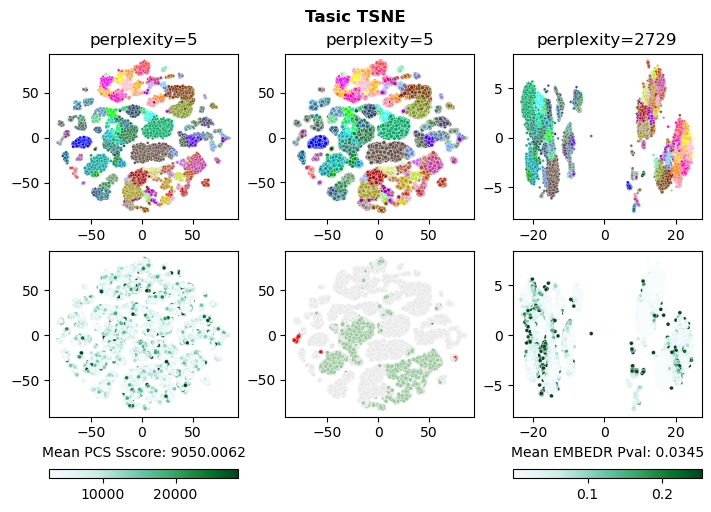

In [11]:
methods = ['pcs_ss', 'scdeed', 'embedr', 'medal']
pcs_ss_best, scdeed_best, embedr_best, medal_best = 5, 2729, 2729, 6000

teacher_embed = dict.fromkeys(methods)
for m in methods:
    teacher_embed[m] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_tsne_{locals()[f'{m}_best']}_0_train.npy")

#import og indices
indices = np.load(Path(PATH_PREFIX) / "MEDAL/comparisons/data/tasic_og_idx_1.npy")
pcs_df = pd.read_csv(Path(PATH_PREFIX) /'MEDAL/comparisons/results_pcs/tasic_train_small/X_with_best_scores.csv')
per_sample_pcs_ss = pcs_df[f'sscore_meanbest_{pcs_ss_best}']

embedr_df = pd.read_csv(Path(PATH_PREFIX) / 'MEDAL/comparisons/results_embedr_tsne/tasic_train/X_with_best_scores.csv')
per_sample_embedr = embedr_df[f'embedr_pval_meanbest_{embedr_best}']

scdeed_df = pd.read_csv(Path(PATH_PREFIX) / "MEDAL/comparisons/results_scdeed_tsne/tsne_best_tasic_train_full_results.csv", index_col=0)
per_sample_scdeed = split_scdeed_labels(scdeed_df, scdeed_best)['label']
palette_scdeed = {'dubious': 'red', 'intermediate': '#e8e8e8', 'trustworthy': "#9cc99f"}

cmap = sns.color_palette("BuGn", as_cmap=True)
fig, axes = plt.subplots(2,3, figsize=(7, 5), constrained_layout=True)
axes_flat = axes.flatten()

# 1st column - PCS Sscore
sns.scatterplot(x=teacher_embed['pcs_ss'][indices,0], y=teacher_embed['pcs_ss'][indices,1], s=4, hue=y[indices], palette=tasic_palette, legend=True, ax = axes_flat[0])
sns.scatterplot(x=teacher_embed['pcs_ss'][indices,0], y=teacher_embed['pcs_ss'][indices,1], hue=per_sample_pcs_ss, palette=cmap, 
                hue_norm=plt.Normalize(vmin=np.quantile(per_sample_pcs_ss, 0.025), vmax=np.quantile(per_sample_pcs_ss, 0.975)), 
                s=8,legend=False, rasterized=True, ax = axes_flat[3])
handles, labels = axes_flat[0].get_legend_handles_labels()
if getattr(axes_flat[0], "legend_", None) is not None:
    axes_flat[0].legend_.remove()
    # make one shared legend for the whole figure
    # fig.legend(handles, labels,loc='center', bbox_to_anchor=(1.06, 0.52), frameon=False, title='Cluster', ncol=1, fontsize=15, markerscale=5, title_fontsize=15)
    
axes_flat[0].set_title(f"perplexity={pcs_ss_best}")
axes_flat[3].set_xlabel(f"Mean PCS Sscore: {per_sample_pcs_ss.mean():.4f}")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=np.quantile(per_sample_pcs_ss, 0.025), vmax=np.quantile(per_sample_pcs_ss, 0.975)))
fig.colorbar(sm, ax=axes_flat[3], orientation="horizontal")

# 2nd column - Scdeed
sns.scatterplot(x=teacher_embed['scdeed'][:, 0], y=teacher_embed['scdeed'][:, 1], 
                ax=axes_flat[1], s=8, hue=y, legend=False, palette=tasic_palette)
sns.scatterplot(x=teacher_embed['scdeed'][:, 0], y=teacher_embed['scdeed'][:, 1], 
                ax=axes_flat[4], s=8, hue = per_sample_scdeed, palette = palette_scdeed, legend=False)
axes_flat[1].set_title(f"perplexity={scdeed_best}")

# 3rd column - EMBEDR Pscore
sns.scatterplot(x=teacher_embed['embedr'][:,0], y=teacher_embed['embedr'][:,1], s=4, hue=y, palette=tasic_palette, legend=False, ax = axes_flat[2])
sns.scatterplot(x=teacher_embed['embedr'][:,0], y=teacher_embed['embedr'][:,1], hue=per_sample_embedr, palette=cmap, 
                hue_norm=plt.Normalize(vmin=np.quantile(per_sample_embedr, 0.025), vmax=np.quantile(per_sample_embedr, 0.975)), 
                s=8,legend=False, rasterized=True, ax = axes_flat[5])
axes_flat[2].set_title(f"perplexity={embedr_best}")
axes_flat[5].set_xlabel(f"Mean EMBEDR Pval: {per_sample_embedr.mean():.4f}")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=np.quantile(per_sample_embedr, 0.025), vmax=np.quantile(per_sample_embedr, 0.975)))
fig.colorbar(sm, ax=axes_flat[5], orientation="horizontal")

fig.suptitle("Tasic TSNE", fontweight='bold')
plt.show()

In [31]:
from utils import evaluate_methods
methods = ['pcs_ss', 'scdeed', 'embedr', 'medal']
pcs_ss_best, scdeed_best, embedr_best, medal_best = 5, 2729, 1241, 2729

teacher_embed = {}
loaded_id_sets = {}
for m in methods:
    if m in ["embedr", "pcs_ss"]:
        for i in range(1, 11):
            teacher_embed[f'{m}{i}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_tsne_{locals()[f'{m}_best']}_0_train_{i}.npy")
            loaded_id_sets[f'{m.upper()}{i}'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/tasic_og_idx{i}.npy")
    else:
        teacher_embed[m] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_tsne_{locals()[f'{m}_best']}_0_train.npy")
        loaded_id_sets[m.upper()] = range(len(X))


embeddings_by_method = {
    "MEDAL":  (teacher_embed["medal"], student_embed_test_tsne01.detach().numpy()),
#     "EMBEDR": (teacher_embed["embedr"], student_embed_test_tsne02.detach().numpy()),
#     "PCS_SS": (teacher_embed["pcs_ss"], student_embed_test_tsne02.detach().numpy()),   
    "SCDEED": (teacher_embed["scdeed"], student_embed_test_tsne03.detach().numpy()),   
}
embeddings_by_method.update([(f"EMBEDR{i}", (teacher_embed[f"embedr{i}"], student_embed_test_tsne02.detach().numpy())) for i in range(1, 11)])
embeddings_by_method.update([(f"PCS_SS{i}", (teacher_embed[f"pcs_ss{i}"], student_embed_test_tsne03.detach().numpy())) for i in range(1, 11)])

summary_df, per_group_mean_df, per_group_std_df = evaluate_methods(
    embeddings_by_method,
    y,
    y_test,
    cv=10,
    C=1.0,
    max_iter=1000,
    random_state=42,
    return_estimators=True,  # set False to skip per‑group statistics
    id_sets = loaded_id_sets
)

print(summary_df)         # overall metrics (mean±std) per method
print(per_group_mean_df)  # per‑group mean accuracy
print(per_group_std_df) 

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

...

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=10.
  warnings.warn(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/bnc2119/.conda/envs/drd/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modul

          train_accuracy  train_accuracy_std  train_macro_f1  \
method                                                         
EMBEDR3         0.297046            0.005358        0.058845   
EMBEDR5         0.291162            0.004823        0.059748   
EMBEDR7         0.286082            0.004134        0.058751   
EMBEDR9         0.291470            0.006676        0.058576   
EMBEDR8         0.293675            0.005486        0.055397   
EMBEDR4         0.288362            0.008029        0.055046   
EMBEDR6         0.292832            0.006843        0.054141   
EMBEDR2         0.284080            0.004380        0.053596   
EMBEDR10        0.291809            0.003729        0.053015   
EMBEDR1         0.280543            0.005802        0.051781   
SCDEED          0.238253            0.003238        0.037983   
PCS_SS1         0.160868            0.004963        0.022874   
PCS_SS3         0.161440            0.005299        0.022681   
PCS_SS4         0.162328            0.00

In [7]:
from utils import evaluate_methods_trustworthiness_mc

methods = ['pcs_ss', 'scdeed', 'embedr', 'medal']
pcs_ss_best, scdeed_best, embedr_best, medal_best = 5, 2729, 1241, 2729

teacher_embed = {}
loaded_id_sets = {}
for m in methods:
    if m in ["embedr", "pcs_ss"]:
        for i in range(1, 11):
            teacher_embed[f'{m}{i}'] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_tsne_{locals()[f'{m}_best']}_0_train_{i}.npy")
            loaded_id_sets[f'{m.upper()}{i}'] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/tasic_og_idx{i}.npy")
    else:
        if m == "scdeed":
            teacher_embed[m] = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/tasic_train_tsne_{locals()[f'{m}_best']}_0_train_pc4.npy")
        else:
            teacher_embed[m] = np.load(Path(PATH_PREFIX) / f"drd_data/embeddings/cortical_tsne_{locals()[f'{m}_best']}_0_train.npy")
        loaded_id_sets[m.upper()] = range(len(X))


embeddings_by_method = {
    "MEDAL":  (teacher_embed["medal"], student_embed_test_tsne01.detach().numpy()),
#     "EMBEDR": (teacher_embed["embedr"], student_embed_test_tsne02.detach().numpy()),
#     "PCS_SS": (teacher_embed["pcs_ss"], student_embed_test_tsne02.detach().numpy()),   
#     "SCDEED": (teacher_embed["scdeed"], student_embed_test_tsne03.detach().numpy()),   
}
# embeddings_by_method.update([(f"EMBEDR{i}", (teacher_embed[f"embedr{i}"], student_embed_test_tsne02.detach().numpy())) for i in range(1, 11)])
# embeddings_by_method.update([(f"PCS_SS{i}", (teacher_embed[f"pcs_ss{i}"], student_embed_test_tsne03.detach().numpy())) for i in range(1, 11)])


by_k_tsne = pd.DataFrame([])
for k in [10, 50, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
    tw_df = evaluate_methods_trustworthiness_mc(
        X, X_test,
        embeddings_by_method,
        n_neighbors=k,
        n_mc=50,
        frac=0.5,
        random_state=0,
    )
    tw_df['k'] = k
    by_k_tsne = pd.concat([by_k_tsne, tw_df.reset_index()])


In [ ]:
for i in range(1, 11):
    embeddings_by_method = {
        f"EMBEDR{i}": (teacher_embed[f"embedr{i}"], student_embed_test_tsne02.detach().numpy()),
        f"PCS_SS{i}": (teacher_embed[f"pcs_ss{i}"], student_embed_test_tsne03.detach().numpy())
    }
    
    id_set = np.load(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/tasic_og_idx{i}.npy")
    for k in [10, 50, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
        tw_df = evaluate_methods_trustworthiness_mc(
            X[id_set], X_test,
            embeddings_by_method,
            n_neighbors=k,
            n_mc=50,
            frac=0.5,
            random_state=0,
        )
        tw_df['k'] = k
        by_k_tsne = pd.concat([by_k_tsne, tw_df.reset_index()])


In [24]:
# embeddings_by_method = {  
#     "SCDEED": (teacher_embed["scdeed"], student_embed_test_tsne01.detach().numpy()),   
# }
# X_scdeed = pd.read_csv(Path(PATH_PREFIX) / f"MEDAL/comparisons/data/tasic_train_pc4.csv", index_col=0)
# for k in [10, 50, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
#     print("Eval.... k = ", k)
#     tw_df = evaluate_methods_trustworthiness_mc(
#         X_scdeed, X_test,
#         embeddings_by_method,
#         n_neighbors=k,
#         n_mc=50,
#         frac=0.5,
#         random_state=0,
#     )
#     tw_df['k'] = k
#     by_k_tsne = pd.concat([by_k_tsne, tw_df.reset_index()])
tw_df = pd.read_csv('tasic_by_k_tsne.csv', index_col=0)
by_k_tsne = pd.concat([by_k_tsne, tw_df])

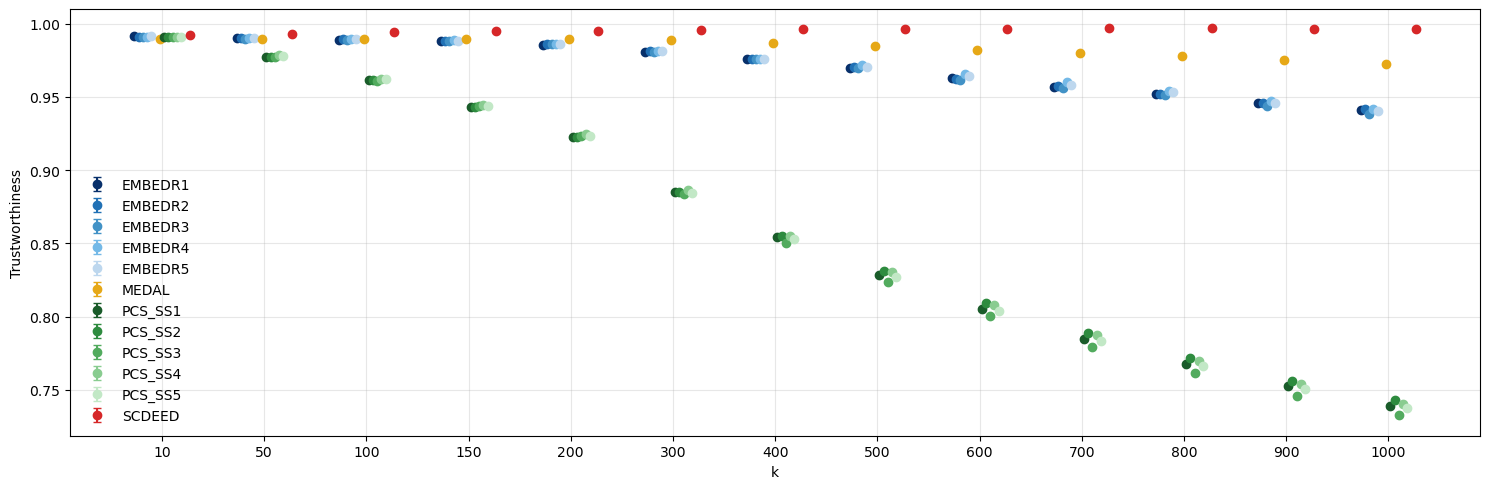

In [28]:
by_k_tsne = by_k_tsne.sort_values(by = ['k', "method"])
groups = by_k_tsne["k"].unique()
methods = by_k_tsne["method"].unique()

color_palette = {
    "EMBEDR1": "#08306b",
    "EMBEDR2": "#2171b5",
    "EMBEDR3": "#4292c6",
    "EMBEDR4": "#74b9e7",
    "EMBEDR5": "#bdd7ee",
    "PCS_SS1": "#1a5c2a",
    "PCS_SS2": "#2e8b3f",
    "PCS_SS3": "#52ab5e",
    "PCS_SS4": "#89cc90",
    "PCS_SS5": "#c2e8c6",
    "MEDAL":   "#e6a817",
    "SCDEED":  "#d62728",
}

group_gap = 1.2        
x = np.arange(len(groups)) * group_gap
z = 1.96  # 95% CI

delta = 0.05  # vertical spacing between methods
offsets = (np.arange(len(methods)) - (len(methods) - 1) / 2) * delta

plt.figure(figsize=(15, 5))

for i, m in enumerate(methods):
    if m in ['EMBEDR6', 'PCS_SS6']: continue
    sub = by_k_tsne[by_k_tsne["method"] == m].set_index("k").loc[groups]
    plt.errorbar(
        x=x + offsets[i],
        y=sub["train_tw_mean"],
        yerr=z * sub["train_tw_stderr"],
        fmt="o",
        capsize=3,
        label=m,
        color=color_palette[m]
    )

plt.xticks(x, groups)
plt.ylabel("Trustworthiness")
plt.xlabel("k")
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


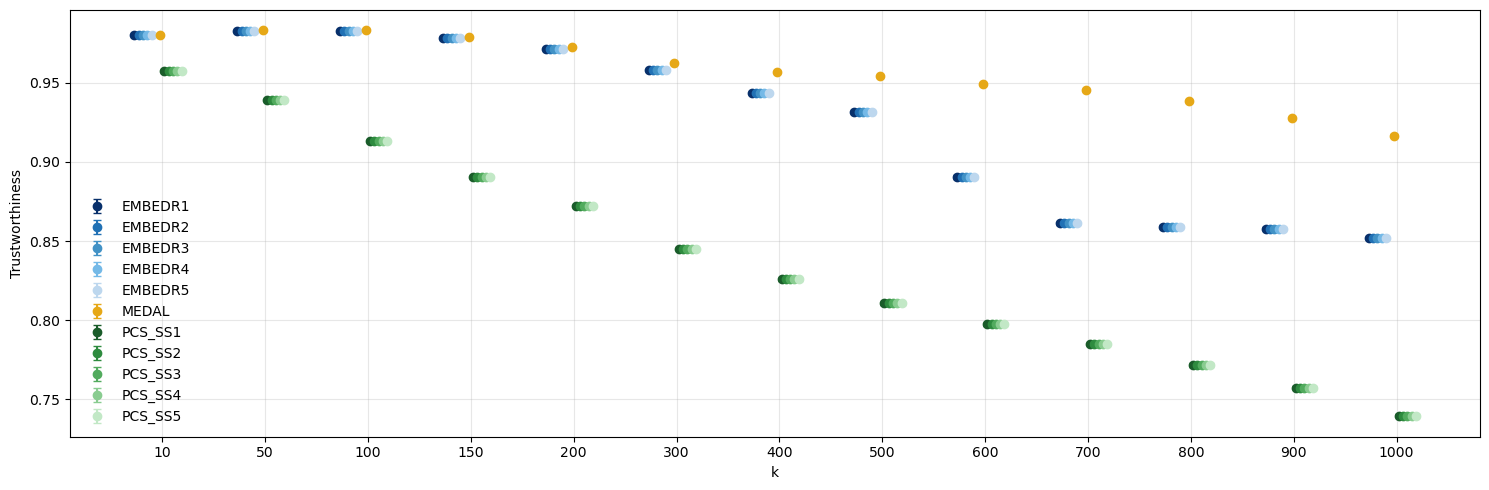

In [29]:
group_gap = 1.2        
x = np.arange(len(groups)) * group_gap
z = 1.96  # 95% CI

delta = 0.05  # vertical spacing between methods
offsets = (np.arange(len(methods)) - (len(methods) - 1) / 2) * delta

plt.figure(figsize=(15, 5))

for i, m in enumerate(methods):
    if m in ['EMBEDR6', 'PCS_SS6', 'SCDEED']: continue
    sub = by_k_tsne[by_k_tsne["method"] == m].set_index("k").loc[groups]
    plt.errorbar(
        x=x + offsets[i],
        y=sub["test_tw_mean"],
        yerr=z * sub["test_tw_stderr"],
        fmt="o",
        capsize=3,
        label=m,
        color=color_palette[m]
    )

plt.xticks(x, groups)
plt.ylabel("Trustworthiness")
plt.xlabel("k")
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [37]:
list_spectral_param = [8, 41, 118]
student_spectral01 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/spectral2_{list_spectral_param[0]}_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_spectral01, student_embed_spectral01 = student_spectral01(torch.tensor(X, dtype=torch.float32))
student_recon_test_spectral01, student_embed_test_spectral01 = student_spectral01(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_spectral01 = np.mean((student_recon_spectral01.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_spectral01 = np.mean((student_recon_test_spectral01.detach().numpy() - X_test)**2, axis=1)

student_spectral02 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/spectral2_{list_spectral_param[1]}_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_spectral02, student_embed_spectral02 = student_spectral02(torch.tensor(X, dtype=torch.float32))
student_recon_test_spectral02, student_embed_test_spectral02 = student_spectral02(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_spectral02 = np.mean((student_recon_spectral02.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_spectral02 = np.mean((student_recon_test_spectral02.detach().numpy() - X_test)**2, axis=1)

student_spectral03 = load_trained_ae(Path(PATH_PREFIX) / f'drd_data/tmp_results/chkpt/cortical/spectral2_{list_spectral_param[2]}_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_spectral03, student_embed_spectral03 = student_spectral03(torch.tensor(X, dtype=torch.float32))
student_recon_test_spectral03, student_embed_test_spectral03 = student_spectral03(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_spectral03 = np.mean((student_recon_spectral03.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_spectral03 = np.mean((student_recon_test_spectral03.detach().numpy() - X_test)**2, axis=1)

loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0
loaded params: 40 | missing=0 | unexpected=0


Text(0.5, 0.98, 'Reconstruction error over embedding after matching Spectral teacher')

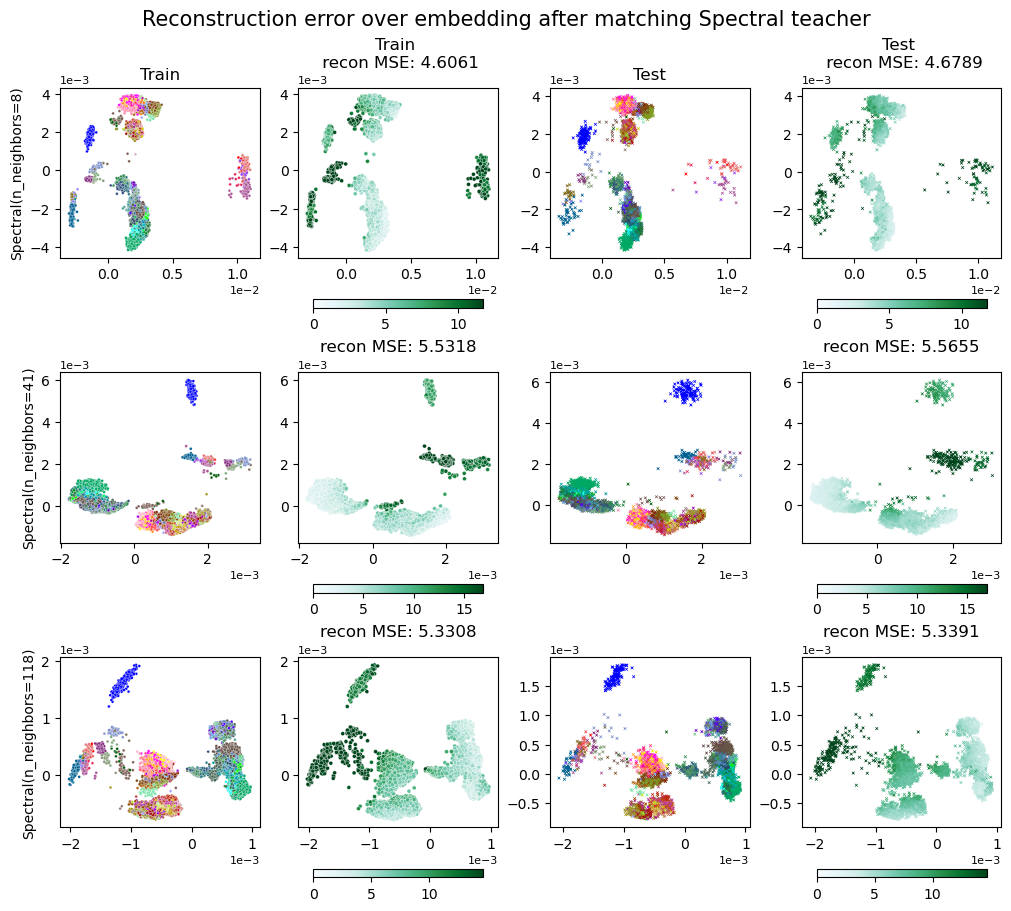

In [38]:
cmap = sns.color_palette("BuGn", as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=16)
fig, axes = plt.subplots(3, 4, figsize=(10, 9), sharey=False, sharex=False, constrained_layout=True)
axes_flat = axes.flatten()
plot_single_param_recon(student_embed_spectral01, student_embed_test_spectral01, per_sample_recon_spectral01, per_sample_recon_test_spectral01, y, y_test, fig, axes_flat[:4], tasic_palette, cmap, 
                        plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test_spectral01, 0.975)), 
                        plot_legend=False)
plot_single_param_recon(student_embed_spectral02, student_embed_test_spectral02, per_sample_recon_spectral02, per_sample_recon_test_spectral02, y, y_test, fig, axes_flat[4:8], tasic_palette, cmap, 
                       plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test_spectral02, 0.975)))
plot_single_param_recon(student_embed_spectral03, student_embed_test_spectral03, per_sample_recon_spectral03, per_sample_recon_test_spectral03, y, y_test, fig, axes_flat[8:12], tasic_palette, cmap, 
                       plt.Normalize(vmin=0, vmax=np.quantile(per_sample_recon_test_spectral01, 0.975)))

for ax in axes_flat:
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
    ax.xaxis.get_offset_text().set_fontsize(8)
    ax.yaxis.get_offset_text().set_fontsize(8)

axes_flat[0].set_ylabel(f"Spectral(n_neighbors={list_spectral_param[0]})")
axes_flat[4].set_ylabel(f"Spectral(n_neighbors={list_spectral_param[1]})")
axes_flat[8].set_ylabel(f"Spectral(n_neighbors={list_spectral_param[2]})")
axes_flat[0].set_title("Train")
axes_flat[1].set_title(f"Train \n recon MSE: {per_sample_recon_spectral01.mean():.4f}")
axes_flat[5].set_title(f"recon MSE: {per_sample_recon_spectral02.mean():.4f}")
axes_flat[9].set_title(f"recon MSE: {per_sample_recon_spectral03.mean():.4f}")

axes_flat[2].set_title("Test")
axes_flat[3].set_title(f"Test \n recon MSE: {per_sample_recon_test_spectral01.mean():.4f}")
axes_flat[7].set_title(f"recon MSE: {per_sample_recon_test_spectral02.mean():.4f}")
axes_flat[11].set_title(f"recon MSE: {per_sample_recon_test_spectral03.mean():.4f}")

fig.suptitle("Reconstruction error over embedding after matching Spectral teacher", fontsize=15)

loaded params: 40 | missing=0 | unexpected=0


Text(0.5, 0.98, 'Reconstruction error over embedding after matching PCA teacher')

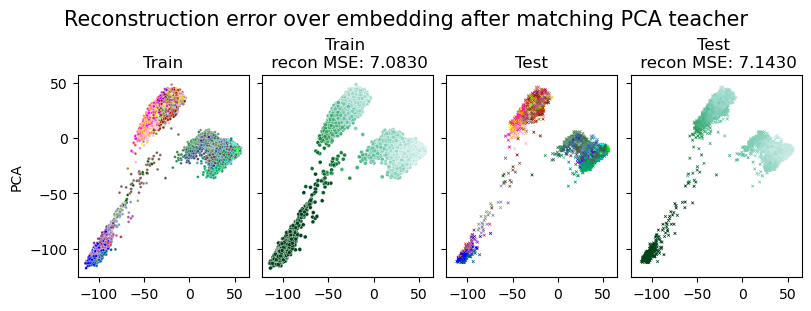

In [14]:
student_pca = load_trained_ae(Path(PATH_PREFIX) / f'tmp_results/chkpt/cortical/pca2_0_ckpts/final.pt',
                input_dim=1000,
                hidden_dims=[309, 1792, 1792, 1792],
                latent_dim=2, batchnorm=True)
student_recon_pca, student_embed_pca = student_pca(torch.tensor(X, dtype=torch.float32))
student_recon_test_pca, student_embed_test_pca = student_pca(torch.tensor(X_test, dtype=torch.float32))
per_sample_recon_pca = np.mean((student_recon_pca.detach().numpy() - X)**2, axis=1)
per_sample_recon_test_pca = np.mean((student_recon_test_pca.detach().numpy() - X_test)**2, axis=1)

cmap = sns.color_palette("BuGn", as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=16)
fig, axes = plt.subplots(1, 4, figsize=(8, 3), sharey=True, sharex=True, constrained_layout=True)
axes_flat = axes.flatten()
plot_single_param_recon(student_embed_pca, student_embed_test_pca, per_sample_recon_pca, per_sample_recon_test_pca, y, y_test, fig, axes_flat[:4], c_dict, cmap, norm, plot_legend=False)

axes_flat[0].set_ylabel("PCA")
axes_flat[0].set_title("Train")
axes_flat[1].set_title(f"Train \n recon MSE: {per_sample_recon_pca.mean():.4f}")

axes_flat[2].set_title("Test")
axes_flat[3].set_title(f"Test \n recon MSE: {per_sample_recon_test_pca.mean():.4f}")

fig.suptitle("Reconstruction error over embedding after matching PCA teacher", fontsize=15)

In [15]:
gluta_subtypes = [
        'L2/3 IT ALM Pld5', 'L2/3 IT ALM S100a3', 'L5 IT ALM Lncb2', 'L5 IT ALM Npy', 
        'L5 IT ALM Tmem163', 'L5 IT ALM Pld5', 'L6 IT ALM Pou3f1', 'L6 IT ALM Tmem163', 
        'L5 PT ALM Slco2a1', 'L5 PT ALM Npy', 'L5 PT ALM AW551984', 'L5 PT ALM Hpgd', 
        'L5 NP ALM Slc17a8', 'L5 NP ALM Npy', 'L5 NP ALM Tmem163', 'L6 CT ALM Pou3f1', 
        'L6 CT ALM Foxp2', 'L6 CT ALM Npas4', 'L6 CT ALM Syt17', 'L6 CT ALM Inpp4b', 
        'L6 CT ALM Cdh18', 'L6 CT ALM Olfr1259', 'L6b ALM Pou3f1', 'L6b ALM Tmem163', 
        'L6b ALM P2ry12', 'L6b ALM Npy', 'L6b ALM Syt17', 'Car3 ALM Pld5', 'Car3 ALM Npy',
        'L2/3 IT VISp Agmat', 'L2/3 IT VISp Adamts2', 'L4 IT VISp Rspo1', 'L4 IT VISp Hsd11b1', 
        'L5 IT VISp Hsd11b1 Endou', 'L5 IT VISp Whrn', 'L5 IT VISp Col27a1', 'L6 IT VISp Penk', 
        'L6 IT VISp Col18a1', 'L5 PT VISp Chrna6', 'L5 PT VISp Lgr5', 'L5 NP VISp Trhr', 
        'L5 NP VISp Cyqp1', 'L6 CT VISp Cpa6', 'L6 CT VISp Gpr139', 'L6 CT VISp Nxph2', 
        'L6b VISp Col8a1', 'L6b VISp Crh', 'Car3 VISp Gm12630',
        'L5 IT S100a10', 'L5 IT Chrna6', 'L5 IT Batf3', 'L5 IT Oxr1', 
        'L6 IT Sulf1', 'L6 IT Car3', 'L6 IT Ptgs2', 'L6 IT Nxph2'
]


gaba_subtypes = [
        'Lamp5 Ntn1 Npy', 'Lamp5 Plch2 Dock5', 'Lamp5 Krt73', 'Lamp5 Lsp1', 
        'Lamp5 Fam19a1 Tmem255a', 'Lamp5 Fam19a1 Pax6', 'Lamp5 Slc35d3', 'Lamp5 Pdlim4',
        'Sncg Calb1/2', 'Sncg Slc17a8', 'Sncg Vip Itpka', 'Sncg Gnu', 
        'Sncg Myp1', 'Sncg Npy', 'Sncg Ptgs2', 'Sncg Slc17a8 2',
        'Vip Lmo1', 'Vip Chat', 'Vip Crispld2', 'Vip Col15a1 Pdk4', 'Vip Htr2c', 
        'Vip Arhgap36', 'Vip Gpc3', 'Vip Parm1', 'Vip Rspo1', 'Vip Mybpc1', 
        'Vip Mybpc1 Lypd1', 'Vip Mab21l1', 'Vip Igfbp4', 'Vip Igfbp6', 
        'Vip Ptprt', 'Vip Lld1', 'Vip Sema3c',
        'Sst Chodl', 'Sst Myh8', 'Sst Tacr3', 'Sst Calb2 Pdlim4', 'Sst Calb2 Necab1', 
        'Sst Crhr2', 'Sst Hpse', 'Sst Esm1', 'Sst Mme Family', 'Sst Tac1', 
        'Sst Npas4', 'Sst Th', 'Sst Crh', 'Sst Pnoc', 'Sst Cbln4', 
        'Sst C1ql3', 'Sst Myh11', 'Sst Chrna2',
        'Pvalb Tpbg', 'Pvalb Reln', 'Pvalb Vipr2', 'Pvalb Ghor2', 'Pvalb Gabra1', 
        'Pvalb Sema3e', 'Pvalb Calb1', 'Pvalb Th', 'Pvalb Axo-axonic (Chandelier)', 'Pvalb Mme'
]

non_neuronal_subtypes = ['Astro Aqp4', 'Astro Myoc', 'Oligo Opalin', 'Oligo Serpinf1', 'Oligo Enpp6', 'OPC Pdcl5', 'Micro Ctss', 'Endo Slc38a5', 'Endo Myct1', 'VLMC Slc6a13', 'VLMC Spp1', 'VLMC Osr1', 'VLMC Lum', 'Peri', 'SMC', 'Macrophage (PVM)']

In [16]:
tsne_recon_labels01_test = pd.DataFrame(np.array([per_sample_recon_test_tsne01, y_class_test]).T, columns=['recon_loss', 'labels'])
tsne_recon_labels_97_5_percentile01_test = tsne_recon_labels01_test.loc[np.where(tsne_recon_labels01_test['recon_loss'] >= tsne_recon_labels01_test['recon_loss'].quantile(0.975)), 'labels'].value_counts()
tsne_recon_labels02_test = pd.DataFrame(np.array([per_sample_recon_test_tsne02, y_class_test]).T, columns=['recon_loss', 'labels'])
tsne_recon_labels_97_5_percentile02_test = tsne_recon_labels02_test.loc[np.where(tsne_recon_labels02_test['recon_loss'] >= tsne_recon_labels02_test['recon_loss'].quantile(0.975)), 'labels'].value_counts()
umap_recon_labels01_test = pd.DataFrame(np.array([per_sample_recon_test_umap01, y_class_test]).T, columns=['recon_loss', 'labels'])
umap_recon_labels_97_5_percentile01_test = umap_recon_labels01_test.loc[np.where(umap_recon_labels01_test['recon_loss'] >= umap_recon_labels01_test['recon_loss'].quantile(0.975)), 'labels'].value_counts()
spectral_recon_labels01_test = pd.DataFrame(np.array([per_sample_recon_test_spectral01, y_class_test]).T, columns=['recon_loss', 'labels'])
spectral_recon_labels_97_5_percentile01_test = spectral_recon_labels01_test.loc[np.where(spectral_recon_labels01_test['recon_loss'] >= spectral_recon_labels01_test['recon_loss'].quantile(0.975)), 'labels'].value_counts()
pca_recon_labels_test = pd.DataFrame(np.array([per_sample_recon_test_pca, y_class_test]).T, columns=['recon_loss', 'labels'])
pca_recon_labels_97_5_percentile_test = pca_recon_labels_test.loc[np.where(pca_recon_labels_test['recon_loss'] >= pca_recon_labels_test['recon_loss'].quantile(0.975)), 'labels'].value_counts()

In [17]:
tsne_recon_labels01 = pd.DataFrame(np.array([per_sample_recon_tsne01, y_class]).T, columns=['recon_loss', 'labels'])
tsne_recon_labels_97_5_percentile01 = tsne_recon_labels01.loc[np.where(tsne_recon_labels01['recon_loss'] >= tsne_recon_labels01['recon_loss'].quantile(0.975)), 'labels'].value_counts()
tsne_recon_labels02 = pd.DataFrame(np.array([per_sample_recon_tsne02, y_class]).T, columns=['recon_loss', 'labels'])
tsne_recon_labels_97_5_percentile02 = tsne_recon_labels02.loc[np.where(tsne_recon_labels02['recon_loss'] >= tsne_recon_labels02['recon_loss'].quantile(0.975)), 'labels'].value_counts()
umap_recon_labels01 = pd.DataFrame(np.array([per_sample_recon_umap01, y_class]).T, columns=['recon_loss', 'labels'])
umap_recon_labels_97_5_percentile01 = umap_recon_labels01.loc[np.where(umap_recon_labels01['recon_loss'] >= umap_recon_labels01['recon_loss'].quantile(0.975)), 'labels'].value_counts()
spectral_recon_labels01 = pd.DataFrame(np.array([per_sample_recon_spectral01, y_class]).T, columns=['recon_loss', 'labels'])
spectral_recon_labels_97_5_percentile01 = spectral_recon_labels01.loc[np.where(spectral_recon_labels01['recon_loss'] >= spectral_recon_labels01['recon_loss'].quantile(0.975)), 'labels'].value_counts()
pca_recon_labels = pd.DataFrame(np.array([per_sample_recon_pca, y_class]).T, columns=['recon_loss', 'labels'])
pca_recon_labels_97_5_percentile = pca_recon_labels.loc[np.where(pca_recon_labels['recon_loss'] >= pca_recon_labels['recon_loss'].quantile(0.975)), 'labels'].value_counts()

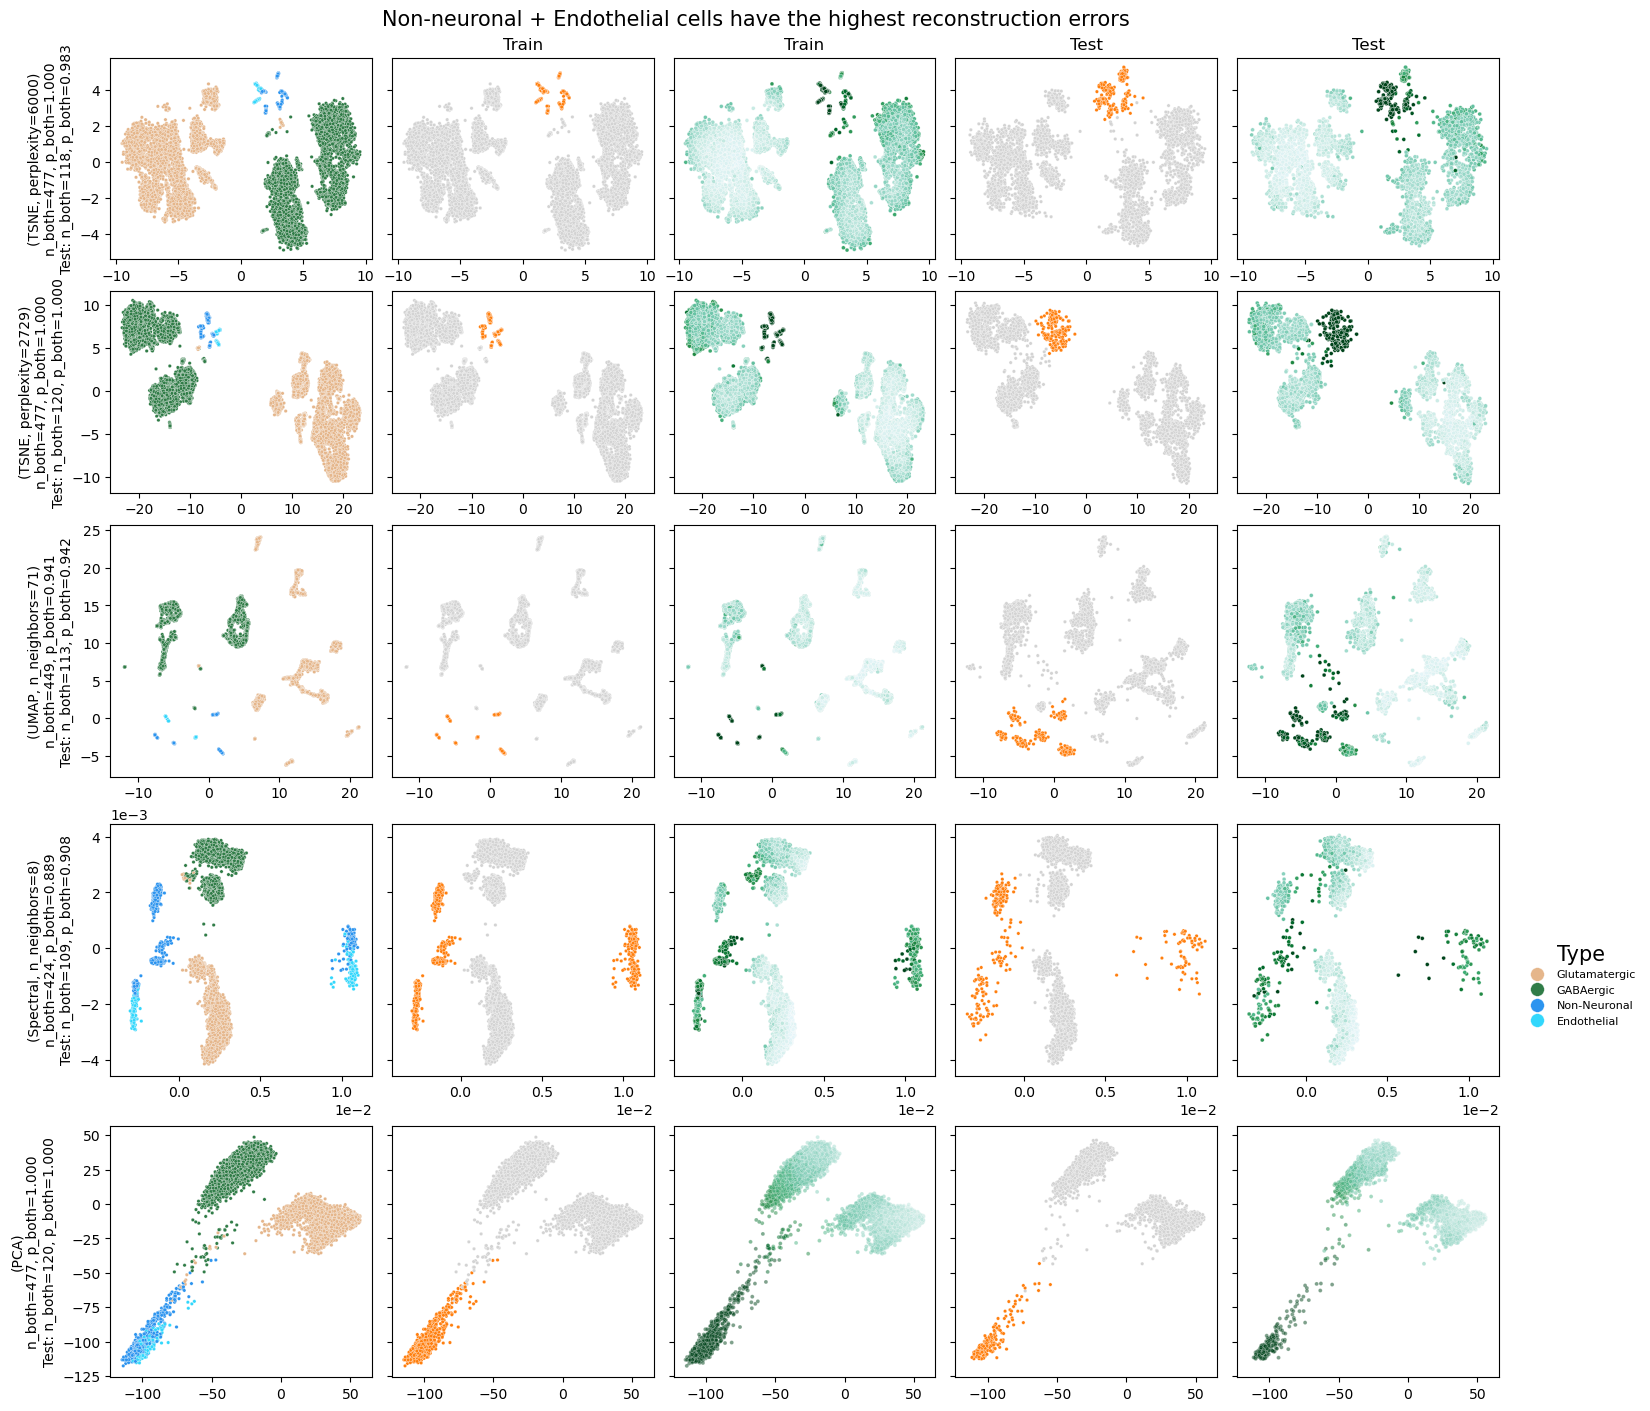

In [18]:
cmap = sns.color_palette("BuGn", as_cmap=True)
norm = plt.Normalize(vmin=0, vmax=16)

is_nonneuron = np.isin(y_class, ['Non-Neuronal', 'Endothelial'])
is_nonneuron_test = np.isin(y_class_test, ['Non-Neuronal', 'Endothelial'])
fig, axes = plt.subplots(5, 5, figsize=(15, 14), sharey='row', sharex='row', constrained_layout=True, height_ratios=[0.2,0.2, 0.25, 0.25, 0.25])
axes_flat = axes.flatten()

# 1st row
sns.scatterplot(x=student_embed_tsne01[:, 0].detach().numpy(), y=student_embed_tsne01[:, 1].detach().numpy(), 
                ax=axes_flat[0], s=6, hue=y_class, legend=True, palette=c_dict_class)
sns.scatterplot(x=student_embed_tsne01[:, 0].detach().numpy(), y=student_embed_tsne01[:, 1].detach().numpy(), 
                ax=axes_flat[1], s=6, hue=is_nonneuron, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
axes_flat[1].set_title("Train")
sum = tsne_recon_labels_97_5_percentile01['Non-Neuronal'] + tsne_recon_labels_97_5_percentile01['Endothelial']
sum_test = tsne_recon_labels_97_5_percentile01_test['Non-Neuronal'] + tsne_recon_labels_97_5_percentile01_test['Endothelial']
axes_flat[0].set_ylabel(f"(TSNE, perplexity={list_tsne_param[0]})\nn_both={sum}, p_both={sum/tsne_recon_labels_97_5_percentile01.sum():.3f}\nTest: n_both={sum_test}, p_both={sum_test/tsne_recon_labels_97_5_percentile01_test.sum():.3f}")

# legend
handles, labels = axes_flat[0].get_legend_handles_labels()
if getattr(axes_flat[0], "legend_", None) is not None: axes_flat[0].legend_.remove()

# make one shared legend for the whole figure
fig.legend(handles, labels, loc='center', bbox_to_anchor=(1.05, 0.3), frameon=False, title='Type', ncol=1, fontsize=8, markerscale=4, title_fontsize=15)

sns.scatterplot(x=student_embed_tsne01[:, 0].detach().numpy(), y=student_embed_tsne01[:, 1].detach().numpy(),
        hue=per_sample_recon_tsne01, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[2])
axes_flat[2].set_title("Train")
sns.scatterplot(x=student_embed_test_tsne01[:, 0].detach().numpy(), y=student_embed_test_tsne01[:, 1].detach().numpy(), 
                ax=axes_flat[3], s=6, hue=is_nonneuron_test, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
axes_flat[3].set_title("Test")

sns.scatterplot(x=student_embed_test_tsne01[:, 0].detach().numpy(), y=student_embed_test_tsne01[:, 1].detach().numpy(),
        hue=per_sample_recon_test_tsne01, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[4])
axes_flat[4].set_title("Test")

# 2nd row
sns.scatterplot(x=student_embed_tsne02[:, 0].detach().numpy(), y=student_embed_tsne02[:, 1].detach().numpy(), 
                ax=axes_flat[5], s=6, hue=y_class, legend=False, palette=c_dict_class)
sum = tsne_recon_labels_97_5_percentile02['Non-Neuronal'] + tsne_recon_labels_97_5_percentile02['Endothelial']
sum_test = tsne_recon_labels_97_5_percentile02_test['Non-Neuronal'] + tsne_recon_labels_97_5_percentile02_test['Endothelial']
axes_flat[5].set_ylabel(f"(TSNE, perplexity={list_tsne_param[1]})\nn_both={sum}, p_both={sum/tsne_recon_labels_97_5_percentile02.sum():.3f}\nTest: n_both={sum_test}, p_both={sum_test/tsne_recon_labels_97_5_percentile02_test.sum():.3f}")
sns.scatterplot(x=student_embed_tsne02[:, 0].detach().numpy(), y=student_embed_tsne02[:, 1].detach().numpy(), 
                ax=axes_flat[6], s=6, hue=is_nonneuron, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_tsne02[:, 0].detach().numpy(), y=student_embed_tsne02[:, 1].detach().numpy(),
        hue=per_sample_recon_tsne02, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[7])
sns.scatterplot(x=student_embed_test_tsne02[:, 0].detach().numpy(), y=student_embed_test_tsne02[:, 1].detach().numpy(), 
                ax=axes_flat[8], s=6, hue=is_nonneuron_test, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_test_tsne02[:, 0].detach().numpy(), y=student_embed_test_tsne02[:, 1].detach().numpy(),
        hue=per_sample_recon_test_tsne02, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[9])

# 3rd row
sns.scatterplot(x=student_embed_umap01[:, 0].detach().numpy(), y=student_embed_umap01[:, 1].detach().numpy(), 
                ax=axes_flat[10], s=6, hue=y_class, legend=False, palette=c_dict_class)
sum = umap_recon_labels_97_5_percentile01['Non-Neuronal'] + umap_recon_labels_97_5_percentile01['Endothelial']
sum_test = umap_recon_labels_97_5_percentile01_test['Non-Neuronal'] + umap_recon_labels_97_5_percentile01_test['Endothelial']
axes_flat[10].set_ylabel(f"(UMAP, n_neighbors={list_umap_param[0]})\nn_both={sum}, p_both={sum/umap_recon_labels_97_5_percentile01.sum():.3f}\nTest: n_both={sum_test}, p_both={sum_test/umap_recon_labels_97_5_percentile01_test.sum():.3f}")
sns.scatterplot(x=student_embed_umap01[:, 0].detach().numpy(), y=student_embed_umap01[:, 1].detach().numpy(), 
                ax=axes_flat[11], s=6, hue=is_nonneuron, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_umap01[:, 0].detach().numpy(), y=student_embed_umap01[:, 1].detach().numpy(),
        hue=per_sample_recon_umap01, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[12])
sns.scatterplot(x=student_embed_test_umap01[:, 0].detach().numpy(), y=student_embed_test_umap01[:, 1].detach().numpy(), 
                ax=axes_flat[13], s=6, hue=is_nonneuron_test, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_test_umap01[:, 0].detach().numpy(), y=student_embed_test_umap01[:, 1].detach().numpy(),
        hue=per_sample_recon_test_umap01, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[14])

# 4th row
sns.scatterplot(x=student_embed_spectral01[:, 0].detach().numpy(), y=student_embed_spectral01[:, 1].detach().numpy(), 
                ax=axes_flat[15], s=6, hue=y_class, legend=False, palette=c_dict_class)
sum = spectral_recon_labels_97_5_percentile01['Non-Neuronal'] + spectral_recon_labels_97_5_percentile01['Endothelial']
sum_test = spectral_recon_labels_97_5_percentile01_test['Non-Neuronal'] + spectral_recon_labels_97_5_percentile01_test['Endothelial']
axes_flat[15].set_ylabel(f"(Spectral, n_neighbors={list_spectral_param[0]})\nn_both={sum}, p_both={sum/spectral_recon_labels_97_5_percentile01.sum():.3f}\nTest: n_both={sum_test}, p_both={sum_test/spectral_recon_labels_97_5_percentile01_test.sum():.3f}")
sns.scatterplot(x=student_embed_spectral01[:, 0].detach().numpy(), y=student_embed_spectral01[:, 1].detach().numpy(), 
                ax=axes_flat[16], s=6, hue=is_nonneuron, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_spectral01[:, 0].detach().numpy(), y=student_embed_spectral01[:, 1].detach().numpy(),
        hue=per_sample_recon_spectral01, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[17])
sns.scatterplot(x=student_embed_test_spectral01[:, 0].detach().numpy(), y=student_embed_test_spectral01[:, 1].detach().numpy(), 
                ax=axes_flat[18], s=6, hue=is_nonneuron_test, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_test_spectral01[:, 0].detach().numpy(), y=student_embed_test_spectral01[:, 1].detach().numpy(),
        hue=per_sample_recon_test_spectral01, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[19])

axes_flat[15].yaxis.set_major_formatter(ticker.ScalarFormatter())
axes_flat[15].xaxis.set_major_formatter(ticker.ScalarFormatter())
axes_flat[15].ticklabel_format(style='sci', axis='both', scilimits=(0,0))

# 5th row
sns.scatterplot(x=student_embed_pca[:, 0].detach().numpy(), y=student_embed_pca[:, 1].detach().numpy(), 
                ax=axes_flat[20], s=6, hue=y_class, legend=False, palette=c_dict_class)
sum = pca_recon_labels_97_5_percentile['Non-Neuronal'] + pca_recon_labels_97_5_percentile['Endothelial']
sum_test = pca_recon_labels_97_5_percentile_test['Non-Neuronal'] + pca_recon_labels_97_5_percentile_test['Endothelial']
axes_flat[20].set_ylabel(f"(PCA)\nn_both={sum}, p_both={sum/pca_recon_labels_97_5_percentile.sum():.3f}\nTest: n_both={sum_test}, p_both={sum_test/pca_recon_labels_97_5_percentile_test.sum():.3f}")
sns.scatterplot(x=student_embed_pca[:, 0].detach().numpy(), y=student_embed_pca[:, 1].detach().numpy(), 
                ax=axes_flat[21], s=6, hue=is_nonneuron, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_pca[:, 0].detach().numpy(), y=student_embed_pca[:, 1].detach().numpy(),
        hue=per_sample_recon_pca, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[22], alpha=0.5)
sns.scatterplot(x=student_embed_test_pca[:, 0].detach().numpy(), y=student_embed_test_pca[:, 1].detach().numpy(), 
                ax=axes_flat[23], s=6, hue=is_nonneuron_test, legend=False, palette={True: "tab:orange", False:"#D3D3D3"})
sns.scatterplot(x=student_embed_test_pca[:, 0].detach().numpy(), y=student_embed_test_pca[:, 1].detach().numpy(),
        hue=per_sample_recon_test_pca, palette=cmap, hue_norm=norm, s=8,legend=False, rasterized=True, ax=axes_flat[24], alpha=0.5)

fig.suptitle(f"Non-neuronal + Endothelial cells have the highest reconstruction errors", fontsize=15)
plt.show()

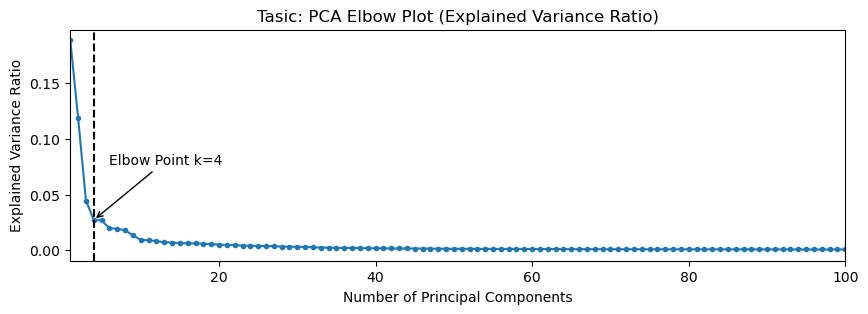

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
path = Path(PATH_PREFIX) / "drd_data/tasic-post-geneSelection_23822x3000-final.csv"
df = pd.read_csv(path)

X = df.select_dtypes(include=["number"])

# Standardize features

# Fit PCA
pca = PCA()
pca.fit(X)

explained_var = pca.explained_variance_ratio_

# Elbow plot: explained variance ratio
plt.figure(figsize=(10, 3))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker='o', markersize=3)
plt.xlabel("Number of Principal Components")
plt.xlim(1, 100)
plt.ylabel("Explained Variance Ratio")
plt.axvline(x=4, ls='--', c='black')
# annotate the elbow point
plt.annotate('Elbow Point k=4', xy=(4, explained_var[3]), xytext =(6, explained_var[3]+0.05),
             arrowprops=dict(facecolor='black', arrowstyle='->'),)
plt.title("Tasic: PCA Elbow Plot (Explained Variance Ratio)")
plt.show()